# Data imports

The questions are pulled from a data export of the [questionnaire data](https://docs.google.com/spreadsheets/d/1B5eKzjVdY31_E19fL2t1haIQfqhuo_XAVnV5IJZtY6A/edit?gid=1868758643#gid=1868758643). Response data is retrieved from tennant specific questionnaire answers separated into role specific export files.

## Import Migration Readiness Assement data

Retrieved from Google Sheets CSV Export ("📩 Export Questions").

In [1]:
# Suppress urllib3 OpenSSL compatibility warning (LibreSSL works fine)
import warnings
warnings.filterwarnings('ignore', message='.*urllib3.*OpenSSL.*')

from pathlib import Path
import time
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import openai
from scipy.stats import ttest_1samp, wilcoxon, t as t_dist
from statsmodels.stats.power import TTestPower  # Fixed: was TTestIndPower (two-sample)
from statsmodels.stats.multitest import multipletests

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import gensim
from gensim import corpora
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Statistical configuration
desired_power = 0.80  # Convention is 0.80 (was 0.95)
EFFECT_SMALL = 0.2
EFFECT_MEDIUM = 0.5
EFFECT_LARGE = 0.8
PRACTICAL_SIGNIFICANCE_THRESHOLD = 0.5

def cohens_d_one_sample(data, population_mean=3.0):
    """Calculate Cohen's d for one-sample comparison against neutral."""
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    if sample_std == 0:
        return 0
    return (sample_mean - population_mean) / sample_std

def interpret_effect_size(d):
    """Interpret Cohen's d using conventional thresholds."""
    abs_d = abs(d)
    if abs_d < EFFECT_SMALL:
        return "negligible"
    elif abs_d < EFFECT_MEDIUM:
        return "small"
    elif abs_d < EFFECT_LARGE:
        return "medium"
    else:
        return "large"

def bootstrap_ci(data, confidence=0.95, n_iterations=1000):
    """Calculate bootstrap confidence interval (more robust for small samples)."""
    if len(data) < 3:
        return np.nan, np.nan, np.nan
    
    bootstrap_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) 
                       for _ in range(n_iterations)]
    
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    return np.mean(data), lower, upper

# Load environment variables from .env file
load_dotenv()

# Load questionnaire structure
questionnaire = pd.read_csv('./Questions/export.csv', index_col='ID')

# Configuration Thresholds
threshold_confidence_low = 3
threshold_risk_critical = 2.5
threshold_risk_average = 3
rag_score_low = 3
rag_score_average = 3.9
threshold_statistical_significance = 0.05

In [2]:
# ── Visual theme (matches SVG asset styling) ──────────────────────────────────
# Dark background palette from assets
_BG_DARK = '#1a1a2e'
_BG_MID = '#16213e'
_GRID_GRAY = '#4a5568'
_TEXT_LIGHT = '#cbd5e0'
_TEXT_MID = '#a0aec0'
_TEXT_DIM = '#718096'

# Accent colours used in the SVG assets
MRA_PALETTE = ['#e94560', '#f39c12', '#00d9a5', '#3b82f6', '#8b5cf6', '#ff6b6b', '#f1c40f', '#00f5a0']

plt.rcParams.update({
    # Figure
    'figure.facecolor':    _BG_DARK,
    'figure.edgecolor':    _BG_DARK,
    # Axes
    'axes.facecolor':      _BG_MID,
    'axes.edgecolor':      _GRID_GRAY,
    'axes.labelcolor':     _TEXT_LIGHT,
    'axes.titlecolor':     'white',
    'axes.grid':           True,
    'grid.color':          _GRID_GRAY,
    'grid.alpha':          0.3,
    # Ticks
    'xtick.color':         _TEXT_MID,
    'ytick.color':         _TEXT_MID,
    # Text
    'text.color':          _TEXT_LIGHT,
    'font.family':         'Helvetica Neue',
    'font.size':           12,
    # Legend
    'legend.facecolor':    _BG_MID,
    'legend.edgecolor':    _GRID_GRAY,
    'legend.labelcolor':   _TEXT_LIGHT,
    # Colour cycle
    'axes.prop_cycle':     plt.cycler(color=MRA_PALETTE),
    # Lines
    'lines.linewidth':     2,
    # Savefig (for exports)
    'savefig.facecolor':   _BG_DARK,
    'savefig.edgecolor':   _BG_DARK,
})

# Seaborn overlay – keeps our rcParams but adds seaborn polish
sns.set_style({
    'axes.facecolor':   _BG_MID,
    'figure.facecolor': _BG_DARK,
    'grid.color':       _GRID_GRAY,
    'axes.edgecolor':   _GRID_GRAY,
    'text.color':       _TEXT_LIGHT,
    'xtick.color':      _TEXT_MID,
    'ytick.color':      _TEXT_MID,
    'axes.labelcolor':  _TEXT_LIGHT,
})

print("✓ MRA dark theme applied – charts will match SVG asset styling")

✓ MRA dark theme applied – charts will match SVG asset styling


Mapping functions for mapping the answers onto a likert scale and for questions to be mapped onto their question ID to make the data more usable

In [3]:
# Likert scale mapping
answer_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5
}

def map_answers(value, question_id):
    if pd.isna(value):  # Check for empty/NaN values
        return 0
    if value in answer_mapping:  # Check if it's a quantitative answer
        weight = questionnaire.loc[question_id, 'Weight'] if question_id in questionnaire.index else 1
        return answer_mapping[value] * weight
    return value  # Return as is for qualitative answers

def map_questions_to_id(question):
    question_to_id = dict(zip(questionnaire['Question'], questionnaire.index))
    return question_to_id.get(question, question)



## Import role based answers

Import answers from the different key user groups, who responded to the questionnaire and separate into qualitative and quantitative results while maintaining 

In [4]:
responses = [
    {'role': 'Engineering', 'fileName': './Responses/Engineering.csv'},
    {'role': 'Product', 'fileName': './Responses/Product.csv'},
    {'role': 'Business', 'fileName': './Responses/Business.csv'},
    {'role': 'Leadership', 'fileName': './Responses/Leadership.csv'},
]

# Identify qualitative and quantitative question IDs
qualitative_ids = questionnaire[questionnaire['Type'] == 'Qualitative'].index
quantitative_ids = questionnaire[questionnaire['Type'] == 'Quantitative'].index

# List to store individual quantitative DataFrames
quantitative_dfs = []
# List to store individual qualitative DataFrames
qualitative_dfs = []
# Set to store roles
roles = set()

# Process responses with role context
for response in responses:
    try:
        # Read CSV and drop the Timestamp column
        df = pd.read_csv(response['fileName'], index_col=None, header=0)
        df = df.drop('Timestamp', axis=1)
        
        # Map the questions to their respective ID
        df.columns = [map_questions_to_id(col) for col in df.columns]
        
        # Align columns with questionnaire IDs
        all_columns = list(questionnaire.index)  # Get all question IDs from the questionnaire
        df = df.reindex(columns=all_columns, fill_value=0)  # Add missing columns with default value 0
        
        # Replace answers with weighted mapped values
        for col in df.columns:
            df[col] = df[col].apply(lambda x: map_answers(x, col))
        
        # Separate the data
        qualitative_data = df[qualitative_ids]
        quantitative_data = df[quantitative_ids]

        # Ensure qualitative data is string
        qualitative_data = qualitative_data.apply(lambda col: col.map(lambda x: x if isinstance(x, str) else np.nan))

        # Ensure quantitative data is numeric
        quantitative_data = quantitative_data.apply(lambda col: col.map(lambda x: x if isinstance(x, (int, float)) else np.nan))
        
        # Create a new DataFrame for qualitative data
        qualitative_df = pd.DataFrame(qualitative_data.values, columns=qualitative_ids)
        qualitative_df.index = df.index  # Set the same index as the original DataFrame

        # Create a new DataFrame for quantitative data
        quantitative_df = pd.DataFrame(quantitative_data.values, columns=quantitative_ids)
        quantitative_df.index = df.index  # Set the same index as the original DataFrame
        
        # Add role context if the DataFrame is not empty
        if not qualitative_df.empty:
            role_column = pd.DataFrame({'role': [response['role']] * len(df)})
            qualitative_df = pd.concat([qualitative_df, role_column], axis=1)  # Combine the role column with the DataFrame
            # Append to list
            qualitative_dfs.append(qualitative_df)
        if not quantitative_df.empty:
            role_column = pd.DataFrame({'role': [response['role']] * len(df)})
            quantitative_df = pd.concat([quantitative_df, role_column], axis=1)
            # Append to list
            quantitative_dfs.append(quantitative_df)
        roles.add(response['role'])  # Add role to the set
    except pd.errors.EmptyDataError:
        print(f"Empty data in file: {response['fileName']}")
    except KeyError as e:
        print(f"Key error: {e} in file: {response['fileName']}")
    except OSError as e:
        print(e)
    except Exception as e:
        print(f"An error occurred while processing {response['fileName']}: {e}")

# Combine DataFrames
if quantitative_dfs:  # Ensure dfs is not empty before concatenating
    combined_quantitative_df = pd.concat(quantitative_dfs, ignore_index=True)
else:
    combined_quantitative_df = pd.DataFrame()  # Create an empty DataFrame if no data is available

# Combine DataFrames
if qualitative_dfs:  # Ensure dfs is not empty before concatenating
    combined_qualitative_df = pd.concat(qualitative_dfs, ignore_index=True)
else:
    combined_qualitative_df = pd.DataFrame()  # Create an empty DataFrame if no data is available

# Print the number of rows in each combined DataFrame
print(f"Loaded combined_quantitative_df responses: {combined_quantitative_df.shape[0]} rows")
print(f"Loaded combined_qualitative_df responses: {combined_qualitative_df.shape[0]} rows")

# Save combined DataFrames to CSV
combined_quantitative_df.to_csv('./Output/combined_quantitative.csv', index=False)
combined_qualitative_df.to_csv('./Output/combined_qualitative.csv', index=False)

Loaded combined_quantitative_df responses: 26 rows
Loaded combined_qualitative_df responses: 26 rows


## Data Insights

### Number of Participants by Role

In [5]:
# Count the number of participants per role
participants_per_role = combined_quantitative_df['role'].value_counts()

# Print the results
print("Number of Participants by role:")

for role, count in participants_per_role.items():
    print(f"{role}: {count} participants")

Number of Participants by role:
Engineering: 10 participants
Product: 8 participants
Business: 4 participants
Leadership: 4 participants


### Distribution of Participants by Role

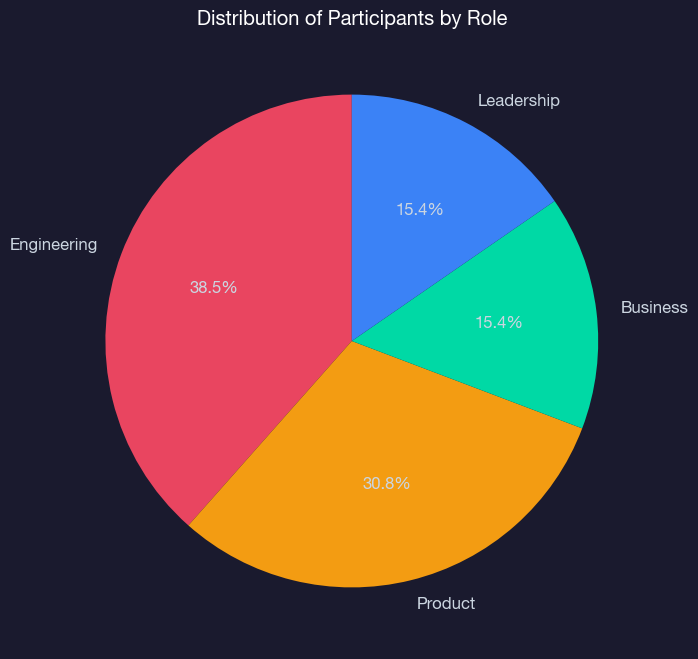

In [6]:
# Create a pie chart for participant roles
plt.figure(figsize=(8, 8))
participants_per_role.plot.pie(autopct='%1.1f%%', startangle=90, labels=participants_per_role.index, colors=MRA_PALETTE,
                               textprops={'color': _TEXT_LIGHT})
plt.title("Distribution of Participants by Role")
plt.ylabel("")  # Remove the y-axis label
plt.show()

# Quantitative Analysis

## 🔹 Domains

### Average score per Domain

In [7]:
# Initialize a dictionary to store the average scores for each domain
domain_scores = {}

# Extract unique domains from the 'Category' column of the questionnaire
domains = questionnaire['Category'].unique()

# Iterate through each domain
for domain in domains:
    # Get the IDs of questions belonging to the current domain
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    
    # Filter the domain_question_ids to include only those present in combined_quantitative_df
    valid_domain_question_ids = [qid for qid in domain_question_ids if qid in combined_quantitative_df.columns]
    
    # Filter the combined_quantitative_df for the current domain's questions
    domain_data = combined_quantitative_df[valid_domain_question_ids]
    # Calculate the average score for answered questions (non-zero values)
    domain_average = domain_data[domain_data > 0].mean(axis=1).mean()
    
    # Round the average to 1 decimal point and store it in the dictionary
    domain_scores[domain] = round(domain_average, 1)

# Print the domain scores
for domain in domain_scores:
    # Check if the domain score is greater than 0
    if domain_scores[domain] > 0:
        # Print the domain and its average score
        print(f"{domain}: {domain_scores[domain]}")
    else:
        # Print a message indicating no valid scores for the domain
        print(f"{domain}: No valid scores")

Architecture & Technology: 3.5
Team Capability: 3.9
Governance & Delivery: 3.0
Integration & Data Readiness: 2.9
Business Alignment & Strategy: 3.5
Cultural Readiness: 3.4


### Role-Based Sentiment Scores with Variance and Range

In [8]:
# Initialize a dictionary to store role-based sentiment scores
role_sentiments = {response['role']: {} for response in responses}

# Iterate through each role
for role in role_sentiments.keys():
    # Filter questions relevant to the current role
    role_question_ids = questionnaire[questionnaire[role]].index
    
    # Group questions by domain
    for domain, domain_questions in questionnaire.loc[role_question_ids].groupby('Category'):
        # Filter the quantitative data for the current domain and role
        valid_columns = [col for col in domain_questions.index if col in combined_quantitative_df.columns]
        domain_data = combined_quantitative_df[valid_columns]
        
        # Calculate the average score for answered questions (non-zero values)
        domain_average = domain_data[domain_data > 0].mean(axis=1).mean()
        
        # Store the rounded average in the role_sentiments dictionary
        role_sentiments[role][domain] = round(domain_average, 1)

# Highlight domains with lower confidence
low_confidence_roles = {}

for role, domains in role_sentiments.items():
    for domain, score in domains.items():
        if score < threshold_confidence_low:
            if domain not in low_confidence_roles:
                low_confidence_roles[domain] = []
            low_confidence_roles[domain].append((role, score))

# Convert role_sentiments to a DataFrame for easier manipulation
role_sentiments_df = pd.DataFrame(role_sentiments)

variance = role_sentiments_df.var(axis=1, skipna=True)
score_range = role_sentiments_df.apply(lambda row: row.max(skipna=True) - row.min(skipna=True), axis=1)

# Add variance and range to the DataFrame
role_sentiments_df['Variance'] = variance
role_sentiments_df['Range'] = score_range

# Print the table with scores, variance, and range
print("\nRole-Based Sentiment Scores with Variance and Range:")
print(role_sentiments_df)

print("\n\n ------------------------------- \n\n")

# Print domains with low confidence
print("\nDomains with particularly low Confidence:")
for domain, roles in low_confidence_roles.items():
    print(f"{domain}:")
    for role, score in roles:
        print(f"  {role}: {score}")


Role-Based Sentiment Scores with Variance and Range:
                               Engineering  Product  Business  Leadership  \
Architecture & Technology              3.5      3.4       NaN         3.9   
Business Alignment & Strategy          3.5      3.5       4.1         3.5   
Cultural Readiness                     3.4      3.4       3.4         3.4   
Governance & Delivery                  3.2      3.2       2.2         3.0   
Integration & Data Readiness           3.0      3.1       2.7         2.6   
Team Capability                        3.9      3.8       NaN         3.9   

                               Variance  Range  
Architecture & Technology      0.070000    0.5  
Business Alignment & Strategy  0.090000    0.6  
Cultural Readiness             0.000000    0.0  
Governance & Delivery          0.226667    1.0  
Integration & Data Readiness   0.056667    0.5  
Team Capability                0.003333    0.1  


 ------------------------------- 



Domains with particularl

### Heatmap

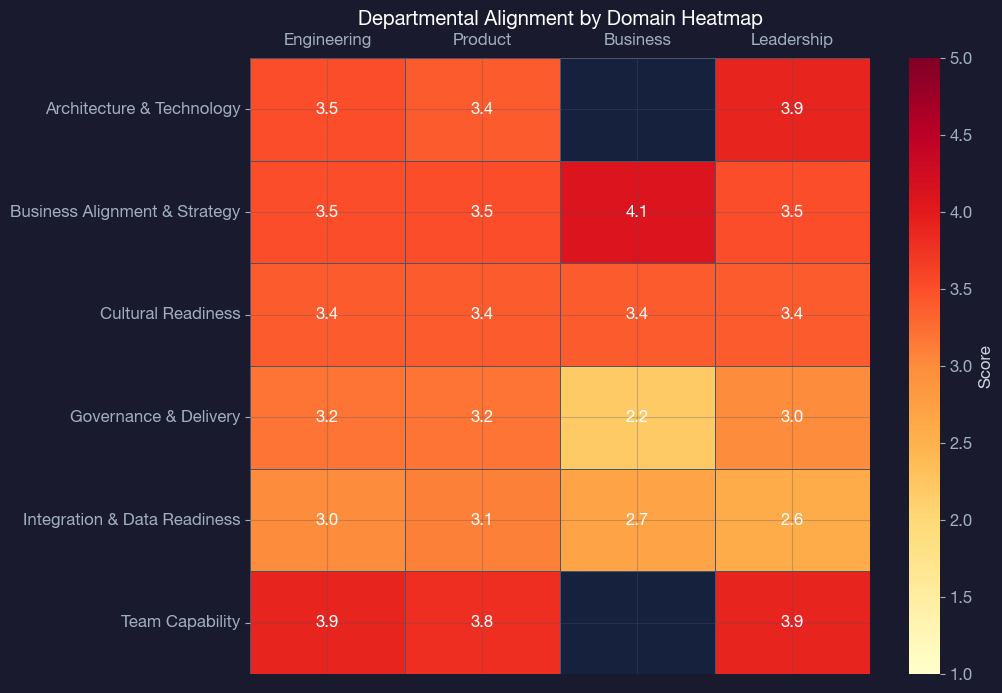

In [9]:
# Convert role_sentiments to a DataFrame for easier plotting

# Convert role_sentiments to a DataFrame for easier plotting
role_sentiments_df = pd.DataFrame(role_sentiments)

# Create the heatmap
plt.figure(figsize=(10, 8))

# Set axis labels and title
plt.title("Departmental Alignment by Domain Heatmap")
plt.tick_params(top=False, labeltop=True, bottom=False, labelbottom=False)

# Create the heatmap with annotations
sns.heatmap(role_sentiments_df, annot=True, cmap="YlOrRd", vmin=1, vmax=5,
            cbar_kws={'label': 'Score'}, fmt=".1f", annot_kws={'color': 'white'},
            linewidths=0.5, linecolor=_GRID_GRAY)

# Show the plot
plt.show()

### Domain based Critical Question Weighting

You can optionally flag critical questions in the report. They aren’t weighted more heavily in the score but:
If average of critical questions < 3, flag domain as "At Risk"
If < 2.5, flag as "Critical Risk"

In [10]:
# Initialize a dictionary to store the risk flags for each domain
domain_risk_flags = {}

# Iterate through each domain
for domain in domains:
    # Get the IDs of questions belonging to the current domain
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    
    # Filter for critical questions within the domain
    critical_question_ids = domain_question_ids[questionnaire.loc[domain_question_ids, 'Critical']]
    
    # Filter the combined_quantitative_df for the critical questions in the current domain
    critical_data = combined_quantitative_df[critical_question_ids]
    
    # Calculate the average score for answered critical questions (non-zero values)
    critical_average = critical_data[critical_data > 0].mean(axis=1).mean()
    
    # Determine the risk flag based on the average score
    if critical_average < threshold_risk_critical:
        domain_risk_flags[domain] = "Critical Risk"
    elif critical_average < threshold_risk_average:
        domain_risk_flags[domain] = "At Risk"
    else:
        domain_risk_flags[domain] = "No Risk"

# Print the risk flags for each domain
for domain in domain_risk_flags:
    # Print the domain and its risk flag
    print(f"{domain}: {domain_risk_flags[domain]}")

Architecture & Technology: No Risk
Business Alignment & Strategy: No Risk
Cultural Readiness: No Risk
Governance & Delivery: At Risk
Integration & Data Readiness: At Risk
Team Capability: No Risk


<Figure size 1200x800 with 0 Axes>

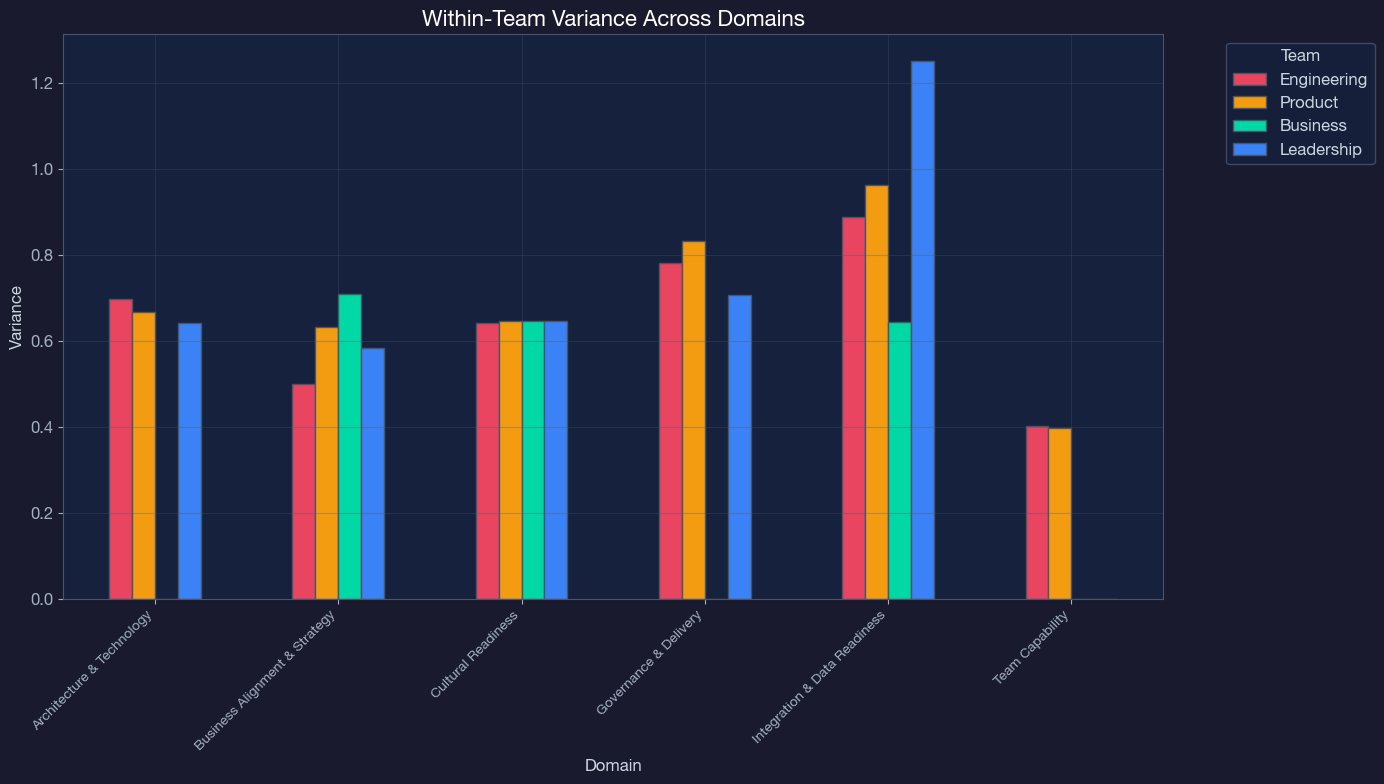

In [11]:
# Calculate within-team variance for each domain
domain_variance_by_team = {}

# Iterate through each role (team)
for role in role_sentiments.keys():
    # Filter questions relevant to the current role
    role_question_ids = questionnaire[questionnaire[role]].index

    # Filter the domain questions for the current role
    role_domain_questions = questionnaire[questionnaire.index.isin(role_question_ids)]

    # Calculate variance for each domain within the current role
    domain_variance_by_team[role] = {}
    for domain, group in role_domain_questions.groupby('Category'):
        # Extract the responses for the current domain
        valid_columns = [col for col in group.index if col in combined_quantitative_df.columns]
        domain_responses = combined_quantitative_df[valid_columns].replace(0, np.nan)
        
        # Calculate variance only if there are multiple responses
        if domain_responses.shape[1] > 1:
            variance = domain_responses.var(axis=1, skipna=True).mean()
        else:
            variance = 0  # Set variance to 0 if there is only one response
        
        domain_variance_by_team[role][domain] = variance

# Convert the variance data to a DataFrame for easier plotting
domain_variance_df = pd.DataFrame(domain_variance_by_team).fillna(0)

# Plot the within-team variance across domains
plt.figure(figsize=(12, 8))
if not domain_variance_df.empty:
    domain_variance_df.plot(kind='bar', figsize=(14, 8), edgecolor=_GRID_GRAY, color=MRA_PALETTE)
else:
    print("No data to plot.")

# Set plot labels and title
plt.title("Within-Team Variance Across Domains", fontsize=16)
plt.xlabel("Domain", fontsize=12)
plt.ylabel("Variance", fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.legend(title="Team", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

### Overall Domain Readiness Score

Calculate a simple mean of all domain scores (equal weights).
Apply RAG logic to overall score for summary visualisation.

| Score Range | Status | Colour | Interpretation |
| ----------- | ------ | ------ | -------------- |
| 4.0 – 5.0 | Ready | 🟢 Green | High maturity and alignment |
| 3.0 – 3.9 | Caution | 🟡 Amber | Some concerns, manageable risk |
| < 3.0 | Not Ready | 🔴 Red | Significant blockers or misalignment |


In [12]:
# Initialize dictionaries to store clustering results
amber_clusters = {}
red_clusters = {}

# Iterate through roles and their domain scores
for role, domains in role_sentiments.items():
    for domain, score in domains.items():
        if score < rag_score_low:
            if domain not in red_clusters:
                red_clusters[domain] = []
            red_clusters[domain].append((role, score))
        elif score < rag_score_average:
            if domain not in amber_clusters:
                amber_clusters[domain] = []
            amber_clusters[domain].append((role, score))

# Print clustering results
print(f"🔴 Red Clusters (Scores < {rag_score_low}):")
for domain, roles in red_clusters.items():
    print(f"{domain}:")
    for role, score in roles:
        print(f"  {role}: {score}")

print("\n\n ------------------------------- \n\n")

print(f"🟡 Amber Clusters (Scores < {rag_score_average}):")
for domain, roles in amber_clusters.items():
    print(f"{domain}:")
    for role, score in roles:
        print(f"  {role}: {score}")

🔴 Red Clusters (Scores < 3):
Governance & Delivery:
  Business: 2.2
Integration & Data Readiness:
  Business: 2.7
  Leadership: 2.6


 ------------------------------- 


🟡 Amber Clusters (Scores < 3.9):
Architecture & Technology:
  Engineering: 3.5
  Product: 3.4
Business Alignment & Strategy:
  Engineering: 3.5
  Product: 3.5
  Leadership: 3.5
Cultural Readiness:
  Engineering: 3.4
  Product: 3.4
  Business: 3.4
  Leadership: 3.4
Governance & Delivery:
  Engineering: 3.2
  Product: 3.2
  Leadership: 3.0
Integration & Data Readiness:
  Engineering: 3.0
  Product: 3.1
Team Capability:
  Product: 3.8


## 🔹 Themes

### Average scores per Theme

In [13]:
# Initialize a dictionary to store theme-based scores
theme_scores = {}

# Filter out rows with NaN themes
themed_questions = questionnaire.dropna(subset=['Theme'])

# Group questions by theme
for theme, theme_questions in themed_questions.groupby('Theme'):
    # Get the IDs of questions belonging to the current theme
    theme_question_ids = theme_questions.index
    
    # Filter the combined quantitative data for the current theme's questions
    valid_theme_question_ids = [qid for qid in theme_question_ids if qid in combined_quantitative_df.columns]
    theme_data = combined_quantitative_df[valid_theme_question_ids]
    
    # Calculate the average score for answered questions (non-zero values)
    theme_average = theme_data[theme_data > 0].mean(axis=1).mean()
    
    # Store the rounded average in the theme_scores dictionary
    theme_scores[theme] = round(theme_average, 1)

# Print the theme-based scores
print("Theme-Based Scores:")
for theme, score in theme_scores.items():
    print(f"{theme}: {score}")

# highlight themes with low confidence
low_confidence_themes = {}
for theme, score in theme_scores.items():
    if score < threshold_confidence_low:
        low_confidence_themes[theme] = score

print("\n\n ------------------------------- \n\n")

# Print themes with low confidence
print("\nThemes with particularly low Confidence:")
for theme, score in low_confidence_themes.items():
    print(f"{theme}: {score}")

Theme-Based Scores:
Autonomy & Empowerment: 3.7
Clear Ownership: 3.3
Composable Integration: 3.4
Cross-Functional Alignment: 3.2
Data Trust & Stewardship: 3.1
Delivery Friction: 3.6
Legacy Constraints: 3.3
Platform vs. Feature Tension: 3.9
Readiness for Change: 3.4
Strategic Sponsorship: 3.6
Technical Confidence: 3.3
Testing & Quality: 3.2


 ------------------------------- 



Themes with particularly low Confidence:


### Theme-Based Sentiment Scores with Variance and Range

In [14]:
# Initialize a dictionary to store theme scores by role
theme_scores_by_role = {}

# Iterate through each role
for role in role_sentiments.keys():
    # Filter questions relevant to the current role
    role_question_ids = questionnaire[questionnaire[role]].index
    
    # Filter the themed questions for the current role
    role_themed_questions = themed_questions[themed_questions.index.isin(role_question_ids)]
    
    # Calculate theme scores for the current role
    theme_scores_by_role[role] = {
        theme: combined_quantitative_df.loc[:, group.index].replace(0, np.nan).mean(axis=1).mean().round(1)
        for theme, group in role_themed_questions.groupby('Theme')
    }

# Convert theme_scores_by_role to a DataFrame for variance and range calculation
theme_scores_df = pd.DataFrame(theme_scores_by_role)

# Add a column for variance across roles for each theme
# and calculate the variance and range
variance = theme_scores_df.var(axis=1, skipna=True)
score_range = theme_scores_df.apply(lambda row: row.max(skipna=True) - row.min(skipna=True), axis=1)
theme_scores_df['Variance'] = variance
theme_scores_df['Range'] = score_range

# Print the table with values, variance, and range
print("\nTheme Scores by Role with Variance and Range:")
print(theme_scores_df)


Theme Scores by Role with Variance and Range:
                              Engineering  Product  Business  Leadership  \
Autonomy & Empowerment                3.7      3.9       NaN         3.2   
Clear Ownership                       3.1      3.4       3.4         3.1   
Composable Integration                3.4      3.2       NaN         NaN   
Cross-Functional Alignment            3.3      3.4       3.3         3.4   
Data Trust & Stewardship              3.1      NaN       3.2         3.2   
Delivery Friction                     3.7      3.6       NaN         3.1   
Legacy Constraints                    3.3      3.4       3.2         3.2   
Platform vs. Feature Tension          3.9      3.9       NaN         3.9   
Readiness for Change                  3.4      3.4       3.4         3.4   
Strategic Sponsorship                 3.5      3.5       NaN         3.6   
Technical Confidence                  4.0      NaN       2.2         3.4   
Testing & Quality                     3.3

### Heatmap

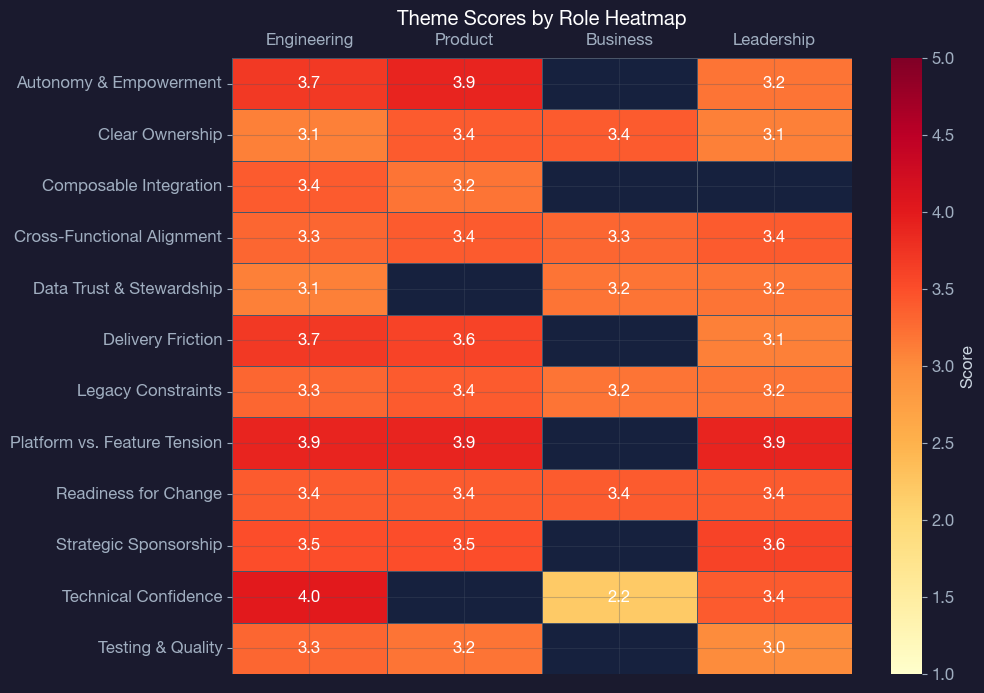

In [15]:
# Convert theme_scores_by_role to a DataFrame for easier plotting
theme_scores_df = pd.DataFrame(theme_scores_by_role)

# Create the heatmap
plt.figure(figsize=(10, 8))

# Set axis labels and title
plt.title("Theme Scores by Role Heatmap")
plt.tick_params(top=False, labeltop=True, bottom=False, labelbottom=False)

# Create the heatmap with annotations
sns.heatmap(theme_scores_df, annot=True, cmap="YlOrRd", vmin=1, vmax=5,
            cbar_kws={'label': 'Score'}, fmt=".1f", annot_kws={'color': 'white'},
            linewidths=0.5, linecolor=_GRID_GRAY)

# Show the plot
plt.show()

### Role-Based variance for each Theme

<Figure size 1200x800 with 0 Axes>

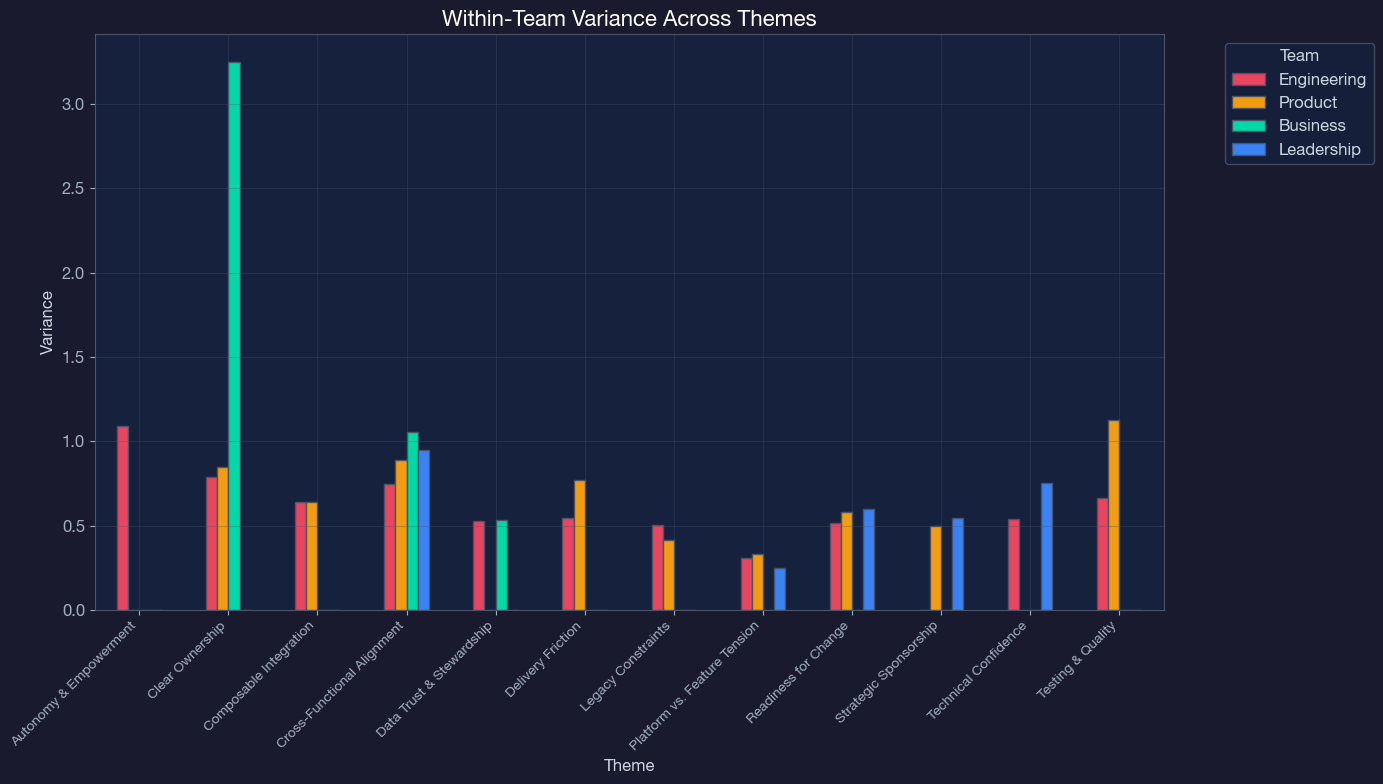

In [16]:
# Calculate within-team variance for each theme
theme_variance_by_team = {}

# Iterate through each role (team)
for role in role_sentiments.keys():
    # Filter questions relevant to the current role
    role_question_ids = questionnaire[questionnaire[role]].index

    # Filter the themed questions for the current role
    role_themed_questions = themed_questions[themed_questions.index.isin(role_question_ids)]

    # Calculate variance for each theme within the current role
    theme_variance_by_team[role] = {}
    for theme, group in role_themed_questions.groupby('Theme'):
        # Extract the responses for the current theme
        theme_responses = combined_quantitative_df.loc[:, group.index].replace(0, np.nan)
        
        # Calculate variance only if there are multiple responses
        if theme_responses.shape[1] > 1:
            variance = theme_responses.var(axis=1, skipna=True).mean()
        else:
            variance = 0  # Set variance to 0 if there is only one response
        
        theme_variance_by_team[role][theme] = variance

# Convert the variance data to a DataFrame for easier plotting
theme_variance_df = pd.DataFrame(theme_variance_by_team).fillna(0)

# Plot the within-team variance across themes
plt.figure(figsize=(12, 8))
if not theme_variance_df.empty:
    theme_variance_df.plot(kind='bar', figsize=(14, 8), edgecolor=_GRID_GRAY, color=MRA_PALETTE)
else:
    print("No data to plot.")

# Set plot labels and title
plt.title("Within-Team Variance Across Themes", fontsize=16)
plt.xlabel("Theme", fontsize=12)
plt.ylabel("Variance", fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.legend(title="Team", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

### Roles with most variance in perception

In [17]:
# Calculate variance for each role across all domains
role_variances = {role: np.nanvar(list(domains.values())) for role, domains in role_sentiments.items()}

# Find the role with the highest variance
max_variance_role = max(role_variances, key=role_variances.get)
max_variance_value = role_variances[max_variance_role]

# Print the results
for role_variane in role_variances.items():
    print(f"{role_variane[0]}: {role_variane[1]:.2f}")

print(f"Role with the most variance: {max_variance_role} (Variance: {max_variance_value:.2f})")

Engineering: 0.08
Product: 0.05
Business: 0.51
Leadership: 0.22
Role with the most variance: Business (Variance: 0.51)


### Theme based Critical Question Weighting

You can optionally flag critical questions in the report. They aren’t weighted more heavily in the score but:
If average of critical questions < 3, flag theme as "At Risk"
If < 2.5, flag as "Critical Risk"

In [18]:
# Initialize a dictionary to store the risk flags for each theme
theme_risk_flags = {}

# Iterate through each theme
for theme, theme_questions in themed_questions.groupby('Theme'):
    # Get the IDs of critical questions belonging to the current theme
    critical_question_ids = theme_questions[theme_questions['Critical']].index
    
    # Filter the combined quantitative data for the critical questions in the current theme
    critical_data = combined_quantitative_df[critical_question_ids]
    
    # Calculate the average score for answered critical questions (non-zero values)
    critical_average = critical_data[critical_data > 0].mean(axis=1).mean()
    
    # Determine the risk flag based on the average score
    if critical_average < threshold_risk_critical:
        theme_risk_flags[theme] = "Critical Risk"
    elif critical_average < threshold_risk_average:
        theme_risk_flags[theme] = "At Risk"
    else:
        theme_risk_flags[theme] = "No Risk"

# Print the risk flags for each theme
for theme, risk_flag in theme_risk_flags.items():
    print(f"{theme}: {risk_flag}")

Autonomy & Empowerment: No Risk
Clear Ownership: No Risk
Composable Integration: No Risk
Cross-Functional Alignment: No Risk
Data Trust & Stewardship: No Risk
Delivery Friction: No Risk
Legacy Constraints: No Risk
Platform vs. Feature Tension: No Risk
Readiness for Change: No Risk
Strategic Sponsorship: No Risk
Technical Confidence: No Risk
Testing & Quality: No Risk


### Overall Theme Readiness Score

Calculate a simple mean of all domain scores (equal weights).
Apply RAG logic to overall score for summary visualisation.

| Score Range | Status | Colour | Interpretation |
| ----------- | ------ | ------ | -------------- |
| 4.0 – 5.0 | Ready | 🟢 Green | High maturity and alignment |
| 3.0 – 3.9 | Caution | 🟡 Amber | Some concerns, manageable risk |
| < 3.0 | Not Ready | 🔴 Red | Significant blockers or misalignment |


In [19]:
# Initialize dictionaries to store clustering results for themes
amber_theme_clusters = {}
red_theme_clusters = {}

# Iterate through roles and their theme scores
for role, themes in theme_scores_by_role.items():
    for theme, score in themes.items():
        if score < rag_score_low:
            if theme not in red_theme_clusters:
                red_theme_clusters[theme] = []
            red_theme_clusters[theme].append((role, score))
        elif score < rag_score_average:
            if theme not in amber_theme_clusters:
                amber_theme_clusters[theme] = []
            amber_theme_clusters[theme].append((role, score))

# Print clustering results for themes
print(f"🔴 Red Theme Clusters (Scores < {rag_score_low}):")
for theme, roles in red_theme_clusters.items():
    print(f"{theme}:")
    for role, score in roles:
        print(f"  {role}: {score}")

print("\n\n ------------------------------- \n\n")

print(f"🟡 Amber Theme Clusters (Scores < {rag_score_average}):")
for theme, roles in amber_theme_clusters.items():
    print(f"{theme}:")
    for role, score in roles:
        print(f"  {role}: {score}")

🔴 Red Theme Clusters (Scores < 3):
Technical Confidence:
  Business: 2.2


 ------------------------------- 


🟡 Amber Theme Clusters (Scores < 3.9):
Autonomy & Empowerment:
  Engineering: 3.7
  Leadership: 3.2
Clear Ownership:
  Engineering: 3.1
  Product: 3.4
  Business: 3.4
  Leadership: 3.1
Composable Integration:
  Engineering: 3.4
  Product: 3.2
Cross-Functional Alignment:
  Engineering: 3.3
  Product: 3.4
  Business: 3.3
  Leadership: 3.4
Data Trust & Stewardship:
  Engineering: 3.1
  Business: 3.2
  Leadership: 3.2
Delivery Friction:
  Engineering: 3.7
  Product: 3.6
  Leadership: 3.1
Legacy Constraints:
  Engineering: 3.3
  Product: 3.4
  Business: 3.2
  Leadership: 3.2
Readiness for Change:
  Engineering: 3.4
  Product: 3.4
  Business: 3.4
  Leadership: 3.4
Strategic Sponsorship:
  Engineering: 3.5
  Product: 3.5
  Leadership: 3.6
Testing & Quality:
  Engineering: 3.3
  Product: 3.2
  Leadership: 3.0
Technical Confidence:
  Leadership: 3.4


## 🔹 Overall rating

### Overall readiness for the migration

| Score Range | Status | Colour | Interpretation |
| ----------- | ------ | ------ | -------------- |
| 4.0 – 5.0 | Ready | 🟢 Green | High maturity and alignment |
| 3.0 – 3.9 | Caution | 🟡 Amber | Some concerns, manageable risk |
| < 3.0 | Not Ready | 🔴 Red | Significant blockers or misalignment |

In [20]:
# Calculate the mean of all domain scores
overall_score = round(np.nanmean([score for domain_scores in role_sentiments.values() for score in domain_scores.values()]), 1)

# Apply RAG logic
if overall_score < rag_score_low:
    rag_status = "🔴 Red"
elif overall_score <= rag_score_average:
    rag_status = "🟡 Amber"
else:
    rag_status = "🟢 Green"

# Print the overall score and RAG status
print(f"Overall Score: {overall_score}")
print(f"RAG Status: {rag_status}")

Overall Score: 3.3
RAG Status: 🟡 Amber


# Executive Decision Support

The following sections provide analysis specifically designed to support investment decisions and stakeholder communication for migration projects.

## 1. Executive Scorecard

A single-view summary designed for board-level discussions. Provides RAG status per domain, overall readiness score, and key findings at a glance.

In [21]:
# =============================================================================
# EXECUTIVE SCORECARD
# =============================================================================

def calculate_domain_scorecard(quant_df, quest_df, role_col='role'):
    """Generate executive scorecard with RAG status per domain."""
    
    scorecard = {}
    domains = quest_df['Category'].unique()
    
    for domain in domains:
        domain_q_ids = quest_df[quest_df['Category'] == domain].index
        valid_q_ids = [q for q in domain_q_ids if q in quant_df.columns]
        
        if not valid_q_ids:
            continue
        
        domain_data = quant_df[valid_q_ids].replace(0, np.nan)
        
        # Overall score
        overall = domain_data.mean().mean()
        
        # Critical questions score
        critical_ids = quest_df[
            (quest_df['Category'] == domain) & 
            (quest_df['Critical'] == True)
        ].index
        critical_ids = [q for q in critical_ids if q in valid_q_ids]
        
        critical_score = domain_data[critical_ids].mean().mean() if critical_ids else overall
        
        # Variance across roles
        if role_col in quant_df.columns:
            role_means = quant_df.groupby(role_col)[valid_q_ids].mean().mean(axis=1)
            variance = role_means.var()
        else:
            variance = domain_data.var().mean()
        
        # RAG status (weighted by critical questions)
        combined = 0.6 * critical_score + 0.4 * overall if not np.isnan(critical_score) else overall
        
        if combined < threshold_risk_critical:
            rag = "🔴 RED"
        elif combined < rag_score_average:
            rag = "🟡 AMBER"
        else:
            rag = "🟢 GREEN"
        
        # Top risks (lowest scoring questions)
        q_means = domain_data.mean().sort_values()
        risks = []
        for q_id in q_means.head(3).index:
            if q_means[q_id] < 3.0:
                q_text = quest_df.loc[q_id, 'Question'][:50]
                risks.append(f"{q_text}... ({q_means[q_id]:.1f})")
        
        # Top strengths (highest scoring questions)
        strengths = []
        for q_id in q_means.tail(3).index:
            if q_means[q_id] >= 4.0:
                q_text = quest_df.loc[q_id, 'Question'][:50]
                strengths.append(f"{q_text}... ({q_means[q_id]:.1f})")
        
        scorecard[domain] = {
            'overall': round(overall, 2) if not np.isnan(overall) else 0,
            'critical': round(critical_score, 2) if not np.isnan(critical_score) else 0,
            'variance': round(variance, 3) if not np.isnan(variance) else 0,
            'rag': rag,
            'risks': risks,
            'strengths': strengths
        }
    
    return scorecard

# Generate scorecard
scorecard = calculate_domain_scorecard(combined_quantitative_df, questionnaire)

# Calculate overall readiness percentage
all_scores = [s['overall'] for s in scorecard.values() if s['overall'] > 0]
readiness_pct = int((np.mean(all_scores) / 5.0) * 100) if all_scores else 0

# Print Executive Summary
print("=" * 80)
print("                    MIGRATION READINESS SCORECARD")
print("=" * 80)
print(f"\n                    OVERALL READINESS: {readiness_pct}%")
print(f"                    Overall Score: {np.mean(all_scores):.1f} / 5.0")
print()

# Domain summary table
print(f"{'Domain':<40} {'Score':>8} {'Critical':>10} {'Variance':>10} {'Status':>10}")
print("-" * 80)

red_count = amber_count = green_count = 0
for domain, scores in scorecard.items():
    print(f"{domain:<40} {scores['overall']:>8.2f} {scores['critical']:>10.2f} {scores['variance']:>10.3f} {scores['rag']:>10}")
    if "RED" in scores['rag']:
        red_count += 1
    elif "AMBER" in scores['rag']:
        amber_count += 1
    else:
        green_count += 1

print("-" * 80)
print(f"Summary: 🔴 {red_count} RED | 🟡 {amber_count} AMBER | 🟢 {green_count} GREEN")

# Key Risks
print(f"\n{'='*80}")
print("TOP RISKS (Scores < 3.0)")
print("=" * 80)
for domain, scores in scorecard.items():
    if scores['risks']:
        print(f"\n{domain}:")
        for risk in scores['risks']:
            print(f"  ⚠️  {risk}")

# Key Strengths
print(f"\n{'='*80}")
print("KEY STRENGTHS (Scores >= 4.0)")
print("=" * 80)
for domain, scores in scorecard.items():
    if scores['strengths']:
        print(f"\n{domain}:")
        for strength in scores['strengths']:
            print(f"  ✓  {strength}")

                    MIGRATION READINESS SCORECARD

                    OVERALL READINESS: 71%
                    Overall Score: 3.6 / 5.0

Domain                                      Score   Critical   Variance     Status
--------------------------------------------------------------------------------
Architecture & Technology                    3.74       3.88      3.257    🟡 AMBER
Team Capability                              4.00       4.07      3.528    🟢 GREEN
Governance & Delivery                        3.27       3.16      1.222    🟡 AMBER
Integration & Data Readiness                 3.21       3.14      2.116    🟡 AMBER
Business Alignment & Strategy                3.85       3.79      1.400    🟡 AMBER
Cultural Readiness                           3.45       3.43      0.491    🟡 AMBER
--------------------------------------------------------------------------------
Summary: 🔴 0 RED | 🟡 5 AMBER | 🟢 1 GREEN

TOP RISKS (Scores < 3.0)

Governance & Delivery:
  ⚠️  Business leaders are

## 2. Alignment Gap Analysis

Identifies questions where stakeholder groups have significantly different perceptions. Large gaps (>1.0 point) indicate misalignment that should be addressed before migration begins.

                    STAKEHOLDER ALIGNMENT ANALYSIS

Total questions with alignment gaps (>1.0 points): 20
Critical questions with gaps: 12
Questions with large gaps (>1.5 points): 10

GAPS BY DOMAIN
                               Count  Avg Gap  Max Gap
category                                              
Architecture & Technology          1     1.10     1.10
Business Alignment & Strategy      2     1.18     1.25
Cultural Readiness                13     1.60     2.35
Governance & Delivery              2     1.36     1.50
Integration & Data Readiness       2     1.62     2.20

TOP ALIGNMENT ISSUES (Requires Stakeholder Discussion)

📊 There is openness to change across the organisation.... [CRITICAL]
   Category: Cultural Readiness
   Gap: 2.35 points
   Engineering: 4.6/5 (optimistic)
   Business: 2.25/5 (pessimistic)
   Product: 3.38/5
   Leadership: 3.5/5

📊 There is organisational energy behind the migration.... [CRITICAL]
   Category: Cultural Readiness
   Gap: 2.0 points
   Leade

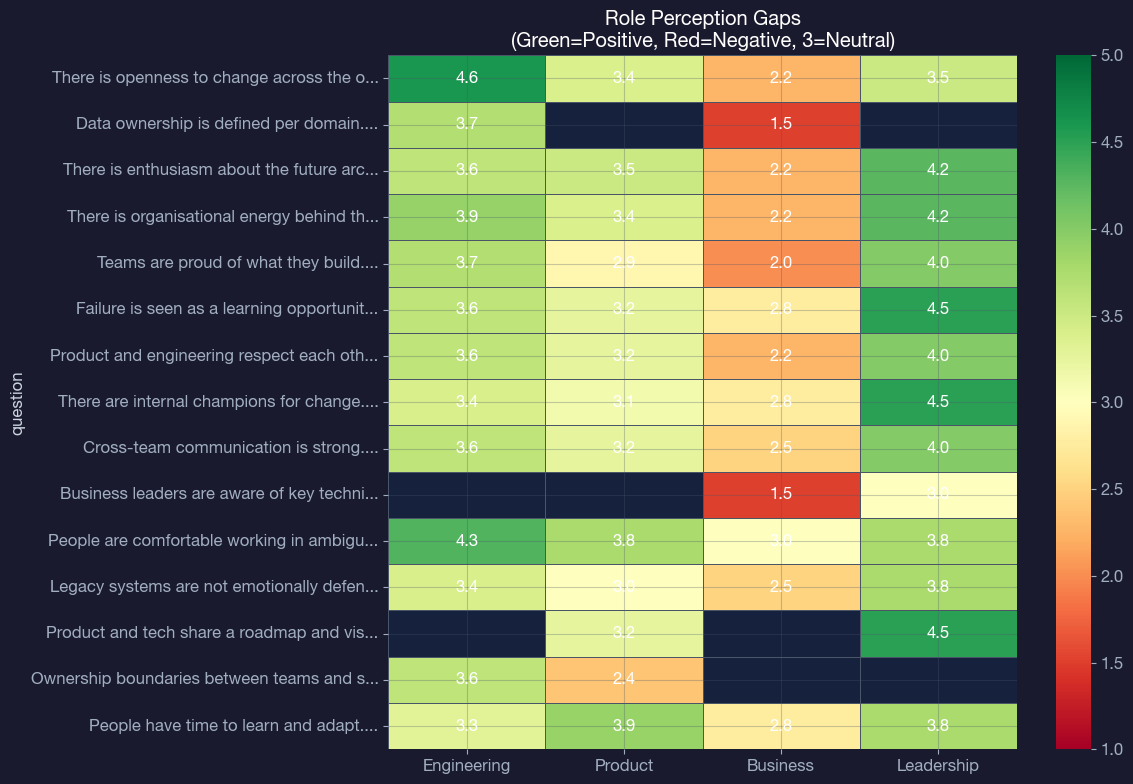

In [22]:
# =============================================================================
# ALIGNMENT GAP ANALYSIS
# =============================================================================

def calculate_alignment_gaps(quant_df, quest_df, role_col='role', gap_threshold=1.0):
    """
    Identify questions where roles have significantly different perceptions.
    A gap > threshold indicates misalignment that should be addressed.
    """
    if role_col not in quant_df.columns:
        print("No role column found - cannot calculate alignment gaps")
        return pd.DataFrame()
    
    gaps = []
    roles = quant_df[role_col].unique()
    
    for q_id in quant_df.columns:
        if q_id == role_col:
            continue
        
        role_means = {}
        for role in roles:
            role_data = quant_df[quant_df[role_col] == role][q_id]
            role_data = role_data[role_data > 0]
            if len(role_data) > 0:
                role_means[role] = role_data.mean()
        
        if len(role_means) < 2:
            continue
        
        max_score = max(role_means.values())
        min_score = min(role_means.values())
        gap = max_score - min_score
        
        if gap >= gap_threshold:
            max_role = max(role_means, key=role_means.get)
            min_role = min(role_means, key=role_means.get)
            
            gaps.append({
                'question_id': q_id,
                'question': quest_df.loc[q_id, 'Question'] if q_id in quest_df.index else str(q_id),
                'category': quest_df.loc[q_id, 'Category'] if q_id in quest_df.index else 'Unknown',
                'critical': quest_df.loc[q_id, 'Critical'] if q_id in quest_df.index else False,
                'gap': round(gap, 2),
                'optimistic_role': max_role,
                'optimistic_score': round(max_score, 2),
                'pessimistic_role': min_role,
                'pessimistic_score': round(min_score, 2),
                'all_role_scores': {r: round(s, 2) for r, s in role_means.items()}
            })
    
    return pd.DataFrame(gaps).sort_values('gap', ascending=False) if gaps else pd.DataFrame()

# Calculate alignment gaps
alignment_gaps = calculate_alignment_gaps(combined_quantitative_df, questionnaire)

print("=" * 80)
print("                    STAKEHOLDER ALIGNMENT ANALYSIS")
print("=" * 80)

if len(alignment_gaps) > 0:
    # Summary statistics
    critical_gaps = alignment_gaps[alignment_gaps['critical'] == True]
    large_gaps = alignment_gaps[alignment_gaps['gap'] >= 1.5]
    
    print(f"\nTotal questions with alignment gaps (>1.0 points): {len(alignment_gaps)}")
    print(f"Critical questions with gaps: {len(critical_gaps)}")
    print(f"Questions with large gaps (>1.5 points): {len(large_gaps)}")
    
    # Gap distribution by category
    print(f"\n{'='*80}")
    print("GAPS BY DOMAIN")
    print("=" * 80)
    gap_by_domain = alignment_gaps.groupby('category').agg({
        'gap': ['count', 'mean', 'max']
    }).round(2)
    gap_by_domain.columns = ['Count', 'Avg Gap', 'Max Gap']
    print(gap_by_domain.to_string())
    
    # Most significant gaps (prioritised by gap size and criticality)
    print(f"\n{'='*80}")
    print("TOP ALIGNMENT ISSUES (Requires Stakeholder Discussion)")
    print("=" * 80)
    
    # Sort by critical first, then by gap size
    priority_gaps = alignment_gaps.sort_values(
        ['critical', 'gap'], 
        ascending=[False, False]
    ).head(10)
    
    for idx, row in priority_gaps.iterrows():
        critical_flag = " [CRITICAL]" if row['critical'] else ""
        print(f"\n📊 {row['question'][:65]}...{critical_flag}")
        print(f"   Category: {row['category']}")
        print(f"   Gap: {row['gap']} points")
        print(f"   {row['optimistic_role']}: {row['optimistic_score']}/5 (optimistic)")
        print(f"   {row['pessimistic_role']}: {row['pessimistic_score']}/5 (pessimistic)")
        
        # Show all role scores
        other_roles = {k: v for k, v in row['all_role_scores'].items() 
                      if k not in [row['optimistic_role'], row['pessimistic_role']]}
        if other_roles:
            for role, score in other_roles.items():
                print(f"   {role}: {score}/5")
    
    # Visualisation: Heatmap of role perceptions for gap questions
    print(f"\n{'='*80}")
    print("ROLE PERCEPTION HEATMAP (Top 15 Gap Questions)")
    print("=" * 80)
    
    # Create a matrix for visualisation
    top_gap_questions = alignment_gaps.head(15)['question_id'].tolist()
    if top_gap_questions:
        roles = combined_quantitative_df['role'].unique()
        heatmap_data = []
        
        for q_id in top_gap_questions:
            row_data = {'question': questionnaire.loc[q_id, 'Question'][:40] + '...' 
                       if q_id in questionnaire.index else str(q_id)}
            for role in roles:
                role_scores = combined_quantitative_df[
                    combined_quantitative_df['role'] == role
                ][q_id].replace(0, np.nan)
                row_data[role] = role_scores.mean()
            heatmap_data.append(row_data)
        
        heatmap_df = pd.DataFrame(heatmap_data).set_index('question')
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='RdYlGn', 
                   center=3, vmin=1, vmax=5, linewidths=0.5, linecolor=_GRID_GRAY,
                   annot_kws={'color': 'white'})
        plt.title('Role Perception Gaps\n(Green=Positive, Red=Negative, 3=Neutral)')
        plt.tight_layout()
        plt.show()
else:
    print("\nNo significant alignment gaps found (all gaps < 1.0 points)")
    print("Stakeholders appear well-aligned on migration readiness perceptions.")

## 3. Investment Prioritisation Matrix

Maps domains by readiness gap (how much work needed) vs business impact (how much it matters for migration success). Produces four quadrants to guide investment decisions:

- **Fix First**: High impact, large gap - critical path items
- **Quick Wins**: High impact, small gap - easy improvements  
- **Plan Carefully**: Low impact, large gap - significant effort, lower priority
- **Monitor**: Low impact, small gap - maintain current state

                    INVESTMENT PRIORITISATION MATRIX

Domain                               Score    Gap  Impact  Priority Action         
-------------------------------------------------------------------------------------
Integration & Data Readiness           3.2    1.8    0.90      1.16 🔴 FIX FIRST    
Governance & Delivery                  3.3    1.7    0.75      1.13 🔴 FIX FIRST    
Architecture & Technology              3.7    1.3    0.95      0.94 🟢 QUICK WINS   
Cultural Readiness                     3.5    1.6    0.65      0.93 🟡 PLAN CAREFULLY
Business Alignment & Strategy          3.9    1.1    0.70      0.90 🔵 MONITOR      
Team Capability                        4.0    1.0    0.85      0.86 🟢 QUICK WINS   

PRIORITISATION QUADRANTS

🔴 FIX FIRST:
  • Integration & Data Readiness (Score: 3.21/5, Gap: 1.79)
  • Governance & Delivery (Score: 3.27/5, Gap: 1.73)

🟢 QUICK WINS:
  • Architecture & Technology (Score: 3.74/5, Gap: 1.26)
  • Team Capability (Score: 4.0/5, Gap: 1.0)



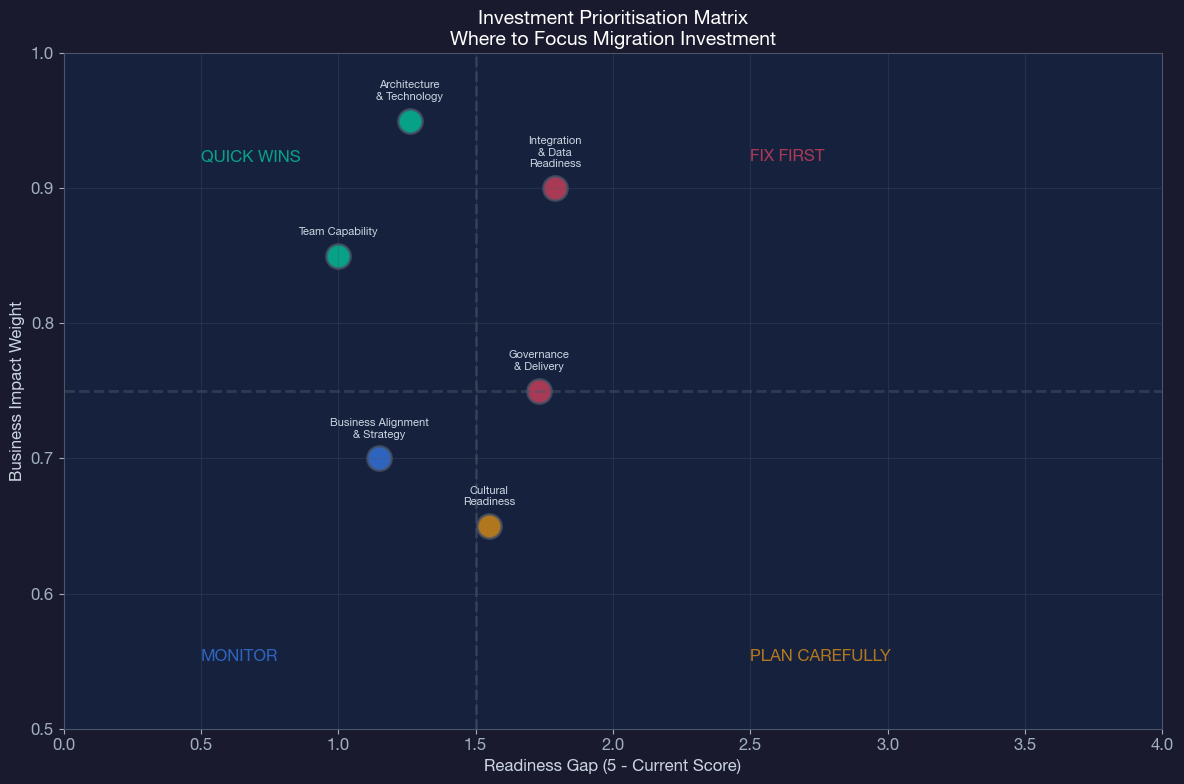

In [23]:
# =============================================================================
# INVESTMENT PRIORITISATION MATRIX
# =============================================================================

# Business impact weights (adjustable based on organisational context)
# Higher = more important for migration success
IMPACT_WEIGHTS = {
    'Architecture & Technology': 0.95,      # Core to migration
    'Integration & Data Readiness': 0.90,   # Critical for composable
    'Team Capability': 0.85,                # Execution depends on this
    'Governance & Delivery': 0.75,          # Enables sustainable change
    'Business Alignment & Strategy': 0.70,  # Ensures support continues
    'Cultural Readiness': 0.65              # Long-term sustainability
}

# Feasibility weights (how easy to improve)
# Higher = easier/faster to address
FEASIBILITY_WEIGHTS = {
    'Architecture & Technology': 0.30,      # Hardest - requires major work
    'Integration & Data Readiness': 0.40,   # Significant effort
    'Team Capability': 0.60,                # Training & hiring possible
    'Governance & Delivery': 0.70,          # Process changes achievable
    'Business Alignment & Strategy': 0.80,  # Alignment workshops help
    'Cultural Readiness': 0.25              # Slowest to change
}

def calculate_priority_matrix(scorecard_data):
    """Calculate investment priority for each domain."""
    
    priorities = []
    
    for domain, scores in scorecard_data.items():
        readiness_gap = 5.0 - scores['overall']  # Gap from perfect
        impact = IMPACT_WEIGHTS.get(domain, 0.5)
        feasibility = FEASIBILITY_WEIGHTS.get(domain, 0.5)
        
        # Priority score formula:
        # - Higher gap = higher priority
        # - Higher impact = higher priority  
        # - Higher feasibility = higher priority (easier wins)
        priority_score = (readiness_gap * 0.4) + (impact * 0.4) + (feasibility * 0.2)
        
        # Determine quadrant
        gap_threshold = 1.5  # Gap from 5.0
        impact_threshold = 0.75
        
        if readiness_gap >= gap_threshold and impact >= impact_threshold:
            quadrant = "🔴 FIX FIRST"
        elif readiness_gap < gap_threshold and impact >= impact_threshold:
            quadrant = "🟢 QUICK WINS"
        elif readiness_gap >= gap_threshold and impact < impact_threshold:
            quadrant = "🟡 PLAN CAREFULLY"
        else:
            quadrant = "🔵 MONITOR"
        
        priorities.append({
            'Domain': domain,
            'Current Score': scores['overall'],
            'Readiness Gap': round(readiness_gap, 2),
            'Business Impact': impact,
            'Feasibility': feasibility,
            'Priority Score': round(priority_score, 2),
            'Quadrant': quadrant,
            'RAG': scores['rag']
        })
    
    return pd.DataFrame(priorities).sort_values('Priority Score', ascending=False)

# Calculate priorities
priority_df = calculate_priority_matrix(scorecard)

print("=" * 80)
print("                    INVESTMENT PRIORITISATION MATRIX")
print("=" * 80)

# Summary table
print(f"\n{'Domain':<35} {'Score':>6} {'Gap':>6} {'Impact':>7} {'Priority':>9} {'Action':<15}")
print("-" * 85)

for _, row in priority_df.iterrows():
    print(f"{row['Domain']:<35} {row['Current Score']:>6.1f} {row['Readiness Gap']:>6.1f} "
          f"{row['Business Impact']:>7.2f} {row['Priority Score']:>9.2f} {row['Quadrant']:<15}")

# Quadrant summary
print(f"\n{'='*80}")
print("PRIORITISATION QUADRANTS")
print("=" * 80)

for quadrant in ["🔴 FIX FIRST", "🟢 QUICK WINS", "🟡 PLAN CAREFULLY", "🔵 MONITOR"]:
    domains_in_quadrant = priority_df[priority_df['Quadrant'] == quadrant]['Domain'].tolist()
    if domains_in_quadrant:
        print(f"\n{quadrant}:")
        for domain in domains_in_quadrant:
            row = priority_df[priority_df['Domain'] == domain].iloc[0]
            print(f"  • {domain} (Score: {row['Current Score']}/5, Gap: {row['Readiness Gap']})")

# Visualisation: 2x2 Matrix
print(f"\n{'='*80}")
print("PRIORITY MATRIX VISUALISATION")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each domain
colors = {'🔴 FIX FIRST': '#e94560', '🟢 QUICK WINS': '#00d9a5', 
          '🟡 PLAN CAREFULLY': '#f39c12', '🔵 MONITOR': '#3b82f6'}

for _, row in priority_df.iterrows():
    color = colors.get(row['Quadrant'], _TEXT_DIM)
    ax.scatter(row['Readiness Gap'], row['Business Impact'], 
               s=300, c=color, alpha=0.7, edgecolors=_GRID_GRAY, linewidth=2)
    ax.annotate(row['Domain'].replace(' & ', '\n& ').replace(' Readiness', '\nReadiness'), 
                (row['Readiness Gap'], row['Business Impact']),
                textcoords="offset points", xytext=(0, 15), 
                ha='center', fontsize=8, fontweight='bold')

# Add quadrant lines and labels
ax.axhline(y=0.75, color=_GRID_GRAY, linestyle='--', alpha=0.5)
ax.axvline(x=1.5, color=_GRID_GRAY, linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(2.5, 0.92, 'FIX FIRST', fontsize=12, fontweight='bold', color='#e94560', alpha=0.7)
ax.text(0.5, 0.92, 'QUICK WINS', fontsize=12, fontweight='bold', color='#00d9a5', alpha=0.7)
ax.text(2.5, 0.55, 'PLAN CAREFULLY', fontsize=12, fontweight='bold', color='#f39c12', alpha=0.7)
ax.text(0.5, 0.55, 'MONITOR', fontsize=12, fontweight='bold', color='#3b82f6', alpha=0.7)

ax.set_xlabel('Readiness Gap (5 - Current Score)', fontsize=12)
ax.set_ylabel('Business Impact Weight', fontsize=12)
ax.set_title('Investment Prioritisation Matrix\nWhere to Focus Migration Investment', fontsize=14)
ax.set_xlim(0, 4)
ax.set_ylim(0.5, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Actionable Recommendations

Translates assessment findings into a concrete action plan with phased recommendations based on priorities, alignment gaps, and budget constraints.

In [24]:
# =============================================================================
# ACTIONABLE RECOMMENDATIONS ENGINE
# =============================================================================

def generate_recommendations(scorecard_data, priority_data, gap_data, overall_readiness):
    """Generate actionable recommendations based on assessment findings."""
    
    recommendations = {
        'immediate': [],      # 0-30 days
        'short_term': [],     # 1-3 months
        'medium_term': [],    # 3-6 months
        'long_term': []       # 6-12 months
    }
    
    # Analyse scorecard for domain-specific recommendations
    for domain, scores in scorecard_data.items():
        rag = scores['rag']
        overall = scores['overall']
        
        # Architecture & Technology
        if domain == 'Architecture & Technology':
            if 'RED' in rag:
                recommendations['immediate'].append(
                    f"🚨 CRITICAL: {domain} scored {overall}/5. Commission architectural assessment "
                    "to map monolith dependencies before any migration work begins."
                )
                recommendations['short_term'].append(
                    "Create architectural decision records (ADRs) for key systems. "
                    "Document API boundaries and integration points."
                )
            elif 'AMBER' in rag:
                recommendations['short_term'].append(
                    f"📋 {domain}: Conduct API inventory and identify candidates for early decoupling. "
                    "Prioritise services with clearest boundaries."
                )
        
        # Team Capability
        elif domain == 'Team Capability':
            if 'RED' in rag:
                recommendations['immediate'].append(
                    f"🚨 CRITICAL: {domain} scored {overall}/5. Assess skill gaps for distributed systems. "
                    "Consider external coaching or key hires before migration begins."
                )
            elif 'AMBER' in rag:
                recommendations['short_term'].append(
                    f"📋 {domain}: Develop training programme for microservices patterns, "
                    "DevOps practices, and cloud-native development."
                )
        
        # Governance & Delivery
        elif domain == 'Governance & Delivery':
            if 'RED' in rag:
                recommendations['short_term'].append(
                    f"⚠️ {domain} scored {overall}/5. Establish clear ownership model (RACI) "
                    "for all systems involved in migration."
                )
            elif 'AMBER' in rag:
                recommendations['medium_term'].append(
                    f"📋 {domain}: Improve CI/CD maturity. Target automated deployments "
                    "for pilot services before broader rollout."
                )
        
        # Integration & Data Readiness
        elif domain == 'Integration & Data Readiness':
            if 'RED' in rag:
                recommendations['immediate'].append(
                    f"🚨 CRITICAL: {domain} scored {overall}/5. Conduct data mapping exercise. "
                    "Identify master data sources and ownership before migration design."
                )
            elif 'AMBER' in rag:
                recommendations['short_term'].append(
                    f"📋 {domain}: Define data contracts and API standards. "
                    "Establish event-driven patterns for new integrations."
                )
        
        # Business Alignment & Strategy
        elif domain == 'Business Alignment & Strategy':
            if 'RED' in rag:
                recommendations['immediate'].append(
                    f"🚨 CRITICAL: {domain} scored {overall}/5. Secure executive sponsorship "
                    "and align on migration success criteria before proceeding."
                )
            elif 'AMBER' in rag:
                recommendations['short_term'].append(
                    f"📋 {domain}: Define clear ROI metrics and communication plan. "
                    "Establish cross-functional steering committee."
                )
        
        # Cultural Readiness
        elif domain == 'Cultural Readiness':
            if 'RED' in rag:
                recommendations['short_term'].append(
                    f"⚠️ {domain} scored {overall}/5. Launch change management programme. "
                    "Identify and empower internal champions before major changes."
                )
            elif 'AMBER' in rag:
                recommendations['medium_term'].append(
                    f"📋 {domain}: Run collaborative design sessions. "
                    "Create safe spaces for teams to experiment with new approaches."
                )
    
    # Alignment-specific recommendations
    if len(gap_data) > 0:
        critical_gaps = gap_data[gap_data['critical'] == True] if 'critical' in gap_data.columns else pd.DataFrame()
        if len(critical_gaps) > 0:
            recommendations['immediate'].append(
                f"🔄 ALIGNMENT: {len(critical_gaps)} critical questions show significant role disagreement. "
                "Schedule cross-functional workshops to align perceptions before migration planning."
            )
        
        large_gaps = gap_data[gap_data['gap'] >= 1.5] if 'gap' in gap_data.columns else pd.DataFrame()
        if len(large_gaps) > 5:
            recommendations['short_term'].append(
                f"🔄 {len(large_gaps)} questions show >1.5 point gaps between roles. "
                "Consider joint planning sessions between Engineering, Product, and Business."
            )
    
    # Overall readiness recommendations
    if overall_readiness < 60:
        recommendations['immediate'].insert(0,
            f"⛔ Overall readiness at {overall_readiness}%. Recommend foundational work "
            "before committing to full migration timeline. Focus on critical gaps first."
        )
    elif overall_readiness < 75:
        recommendations['short_term'].insert(0,
            f"⚠️ Overall readiness at {overall_readiness}%. Migration is feasible with targeted "
            "improvements. Recommend phased approach starting with highest-readiness areas."
        )
    else:
        recommendations['immediate'].insert(0,
            f"✅ Overall readiness at {overall_readiness}%. Organisation shows good foundation "
            "for migration. Proceed with planning while addressing identified gaps."
        )
    
    return recommendations

# Generate recommendations
recommendations = generate_recommendations(
    scorecard, 
    priority_df, 
    alignment_gaps,
    readiness_pct
)

# Print Action Plan
print("=" * 80)
print("                    MIGRATION READINESS ACTION PLAN")
print("=" * 80)
print(f"\n                    Overall Readiness: {readiness_pct}%")

# Print recommendations by phase
phases = [
    ('immediate', '🔴 IMMEDIATE (0-30 days)', 'Critical items requiring immediate attention'),
    ('short_term', '🟠 SHORT-TERM (1-3 months)', 'Foundation-building activities'),
    ('medium_term', '🟡 MEDIUM-TERM (3-6 months)', 'Capability development and process improvement'),
    ('long_term', '🟢 LONG-TERM (6-12 months)', 'Sustained transformation activities')
]

for phase_key, phase_title, phase_desc in phases:
    items = recommendations.get(phase_key, [])
    if items:
        print(f"\n{'='*80}")
        print(f"{phase_title}")
        print(f"{phase_desc}")
        print("=" * 80)
        for i, item in enumerate(items, 1):
            print(f"\n{i}. {item}")

# Budget-based recommendations
print(f"\n{'='*80}")
print("                    BUDGET CONSIDERATIONS")
print("=" * 80)

print("""
💰 LOW BUDGET (Process & Alignment Focus):
   • Stakeholder alignment workshops
   • Documentation and knowledge sharing
   • Process improvements (governance, ownership)
   • Internal capability building through pairing

💰💰 MEDIUM BUDGET (Foundation Building):
   • Targeted training programmes
   • Tooling improvements (CI/CD, observability)
   • Architecture discovery and documentation
   • Pilot migration projects (1-2 bounded contexts)
   • External coaching/consulting

💰💰💰 HIGH BUDGET (Comprehensive Transformation):
   • Full architectural transformation programme
   • Team restructuring for product/platform model
   • Significant hiring for capability gaps
   • Parallel delivery track for migration work
   • External implementation support
""")

# Go/No-Go Summary
print(f"\n{'='*80}")
print("                    GO / NO-GO RECOMMENDATION")
print("=" * 80)

red_domains = [d for d, s in scorecard.items() if 'RED' in s['rag']]
critical_gaps_count = len(alignment_gaps[alignment_gaps['critical'] == True]) if len(alignment_gaps) > 0 and 'critical' in alignment_gaps.columns else 0

if readiness_pct >= 75 and len(red_domains) == 0:
    print(f"""
    ✅ GO - Organisation demonstrates strong readiness for migration
    
    Readiness Score: {readiness_pct}%
    Critical Domains at Risk: {len(red_domains)}
    Critical Alignment Gaps: {critical_gaps_count}
    
    Recommendation: Proceed with migration planning. Address amber areas
    in parallel with initial migration work.
    """)
elif readiness_pct >= 60 and len(red_domains) <= 1:
    print(f"""
    🟡 CONDITIONAL GO - Migration feasible with preparatory work
    
    Readiness Score: {readiness_pct}%
    Critical Domains at Risk: {len(red_domains)} ({', '.join(red_domains) if red_domains else 'None'})
    Critical Alignment Gaps: {critical_gaps_count}
    
    Recommendation: Address red domain(s) before committing to migration
    timeline. Run 2-3 month foundation phase first.
    """)
else:
    print(f"""
    🔴 NOT READY - Significant foundation work required
    
    Readiness Score: {readiness_pct}%
    Critical Domains at Risk: {len(red_domains)} ({', '.join(red_domains)})
    Critical Alignment Gaps: {critical_gaps_count}
    
    Recommendation: Do not commit to migration timeline yet. Focus on 
    immediate actions for 3-6 months, then reassess readiness.
    """)

                    MIGRATION READINESS ACTION PLAN

                    Overall Readiness: 71%

🔴 IMMEDIATE (0-30 days)
Critical items requiring immediate attention

1. 🔄 ALIGNMENT: 12 critical questions show significant role disagreement. Schedule cross-functional workshops to align perceptions before migration planning.

🟠 SHORT-TERM (1-3 months)
Foundation-building activities

1. ⚠️ Overall readiness at 71%. Migration is feasible with targeted improvements. Recommend phased approach starting with highest-readiness areas.

2. 📋 Architecture & Technology: Conduct API inventory and identify candidates for early decoupling. Prioritise services with clearest boundaries.

3. 📋 Integration & Data Readiness: Define data contracts and API standards. Establish event-driven patterns for new integrations.

4. 📋 Business Alignment & Strategy: Define clear ROI metrics and communication plan. Establish cross-functional steering committee.

5. 🔄 10 questions show >1.5 point gaps between roles. Con

### Questions and the distribution of their Responses by Domain

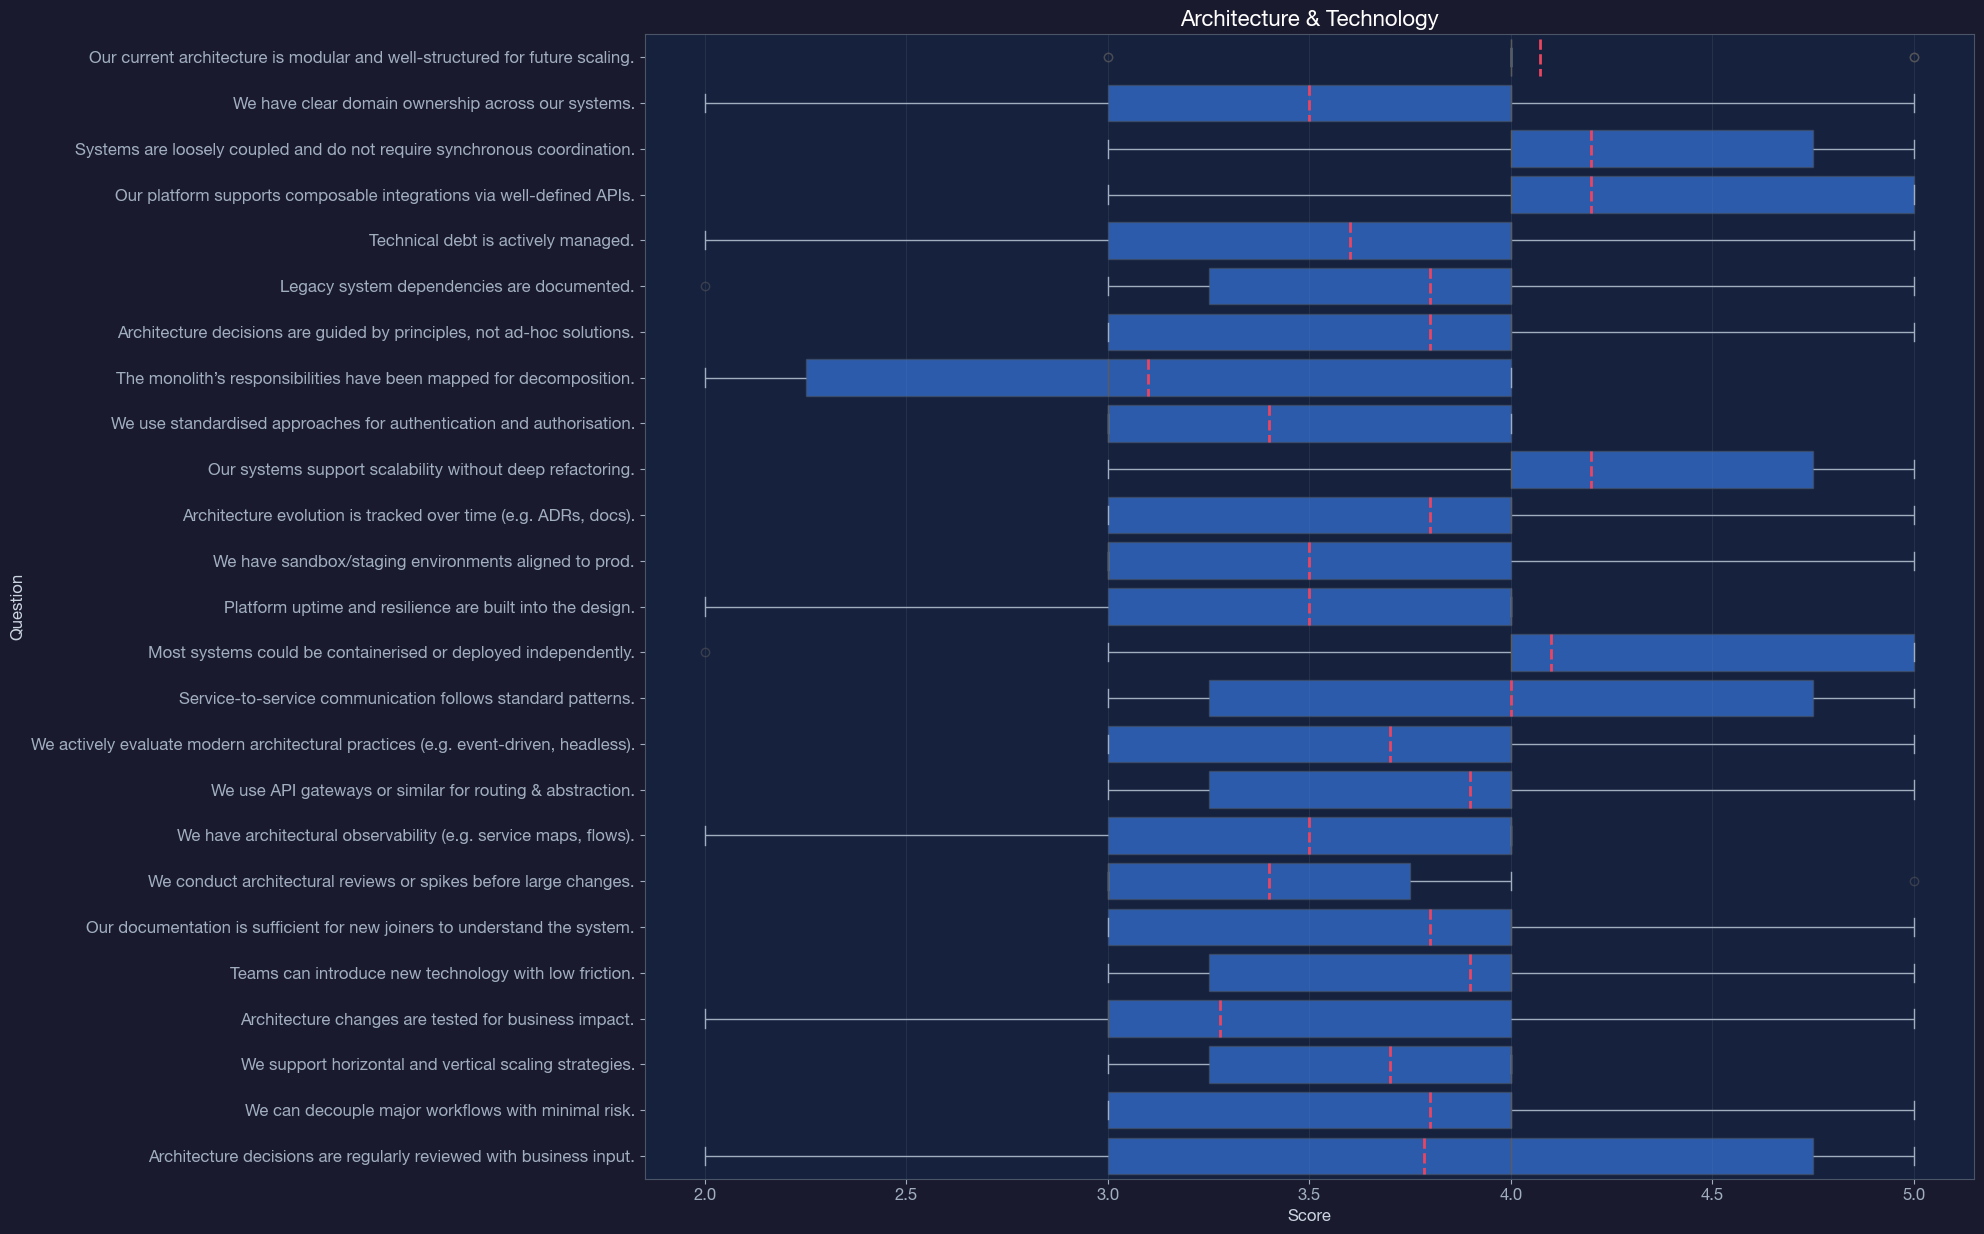

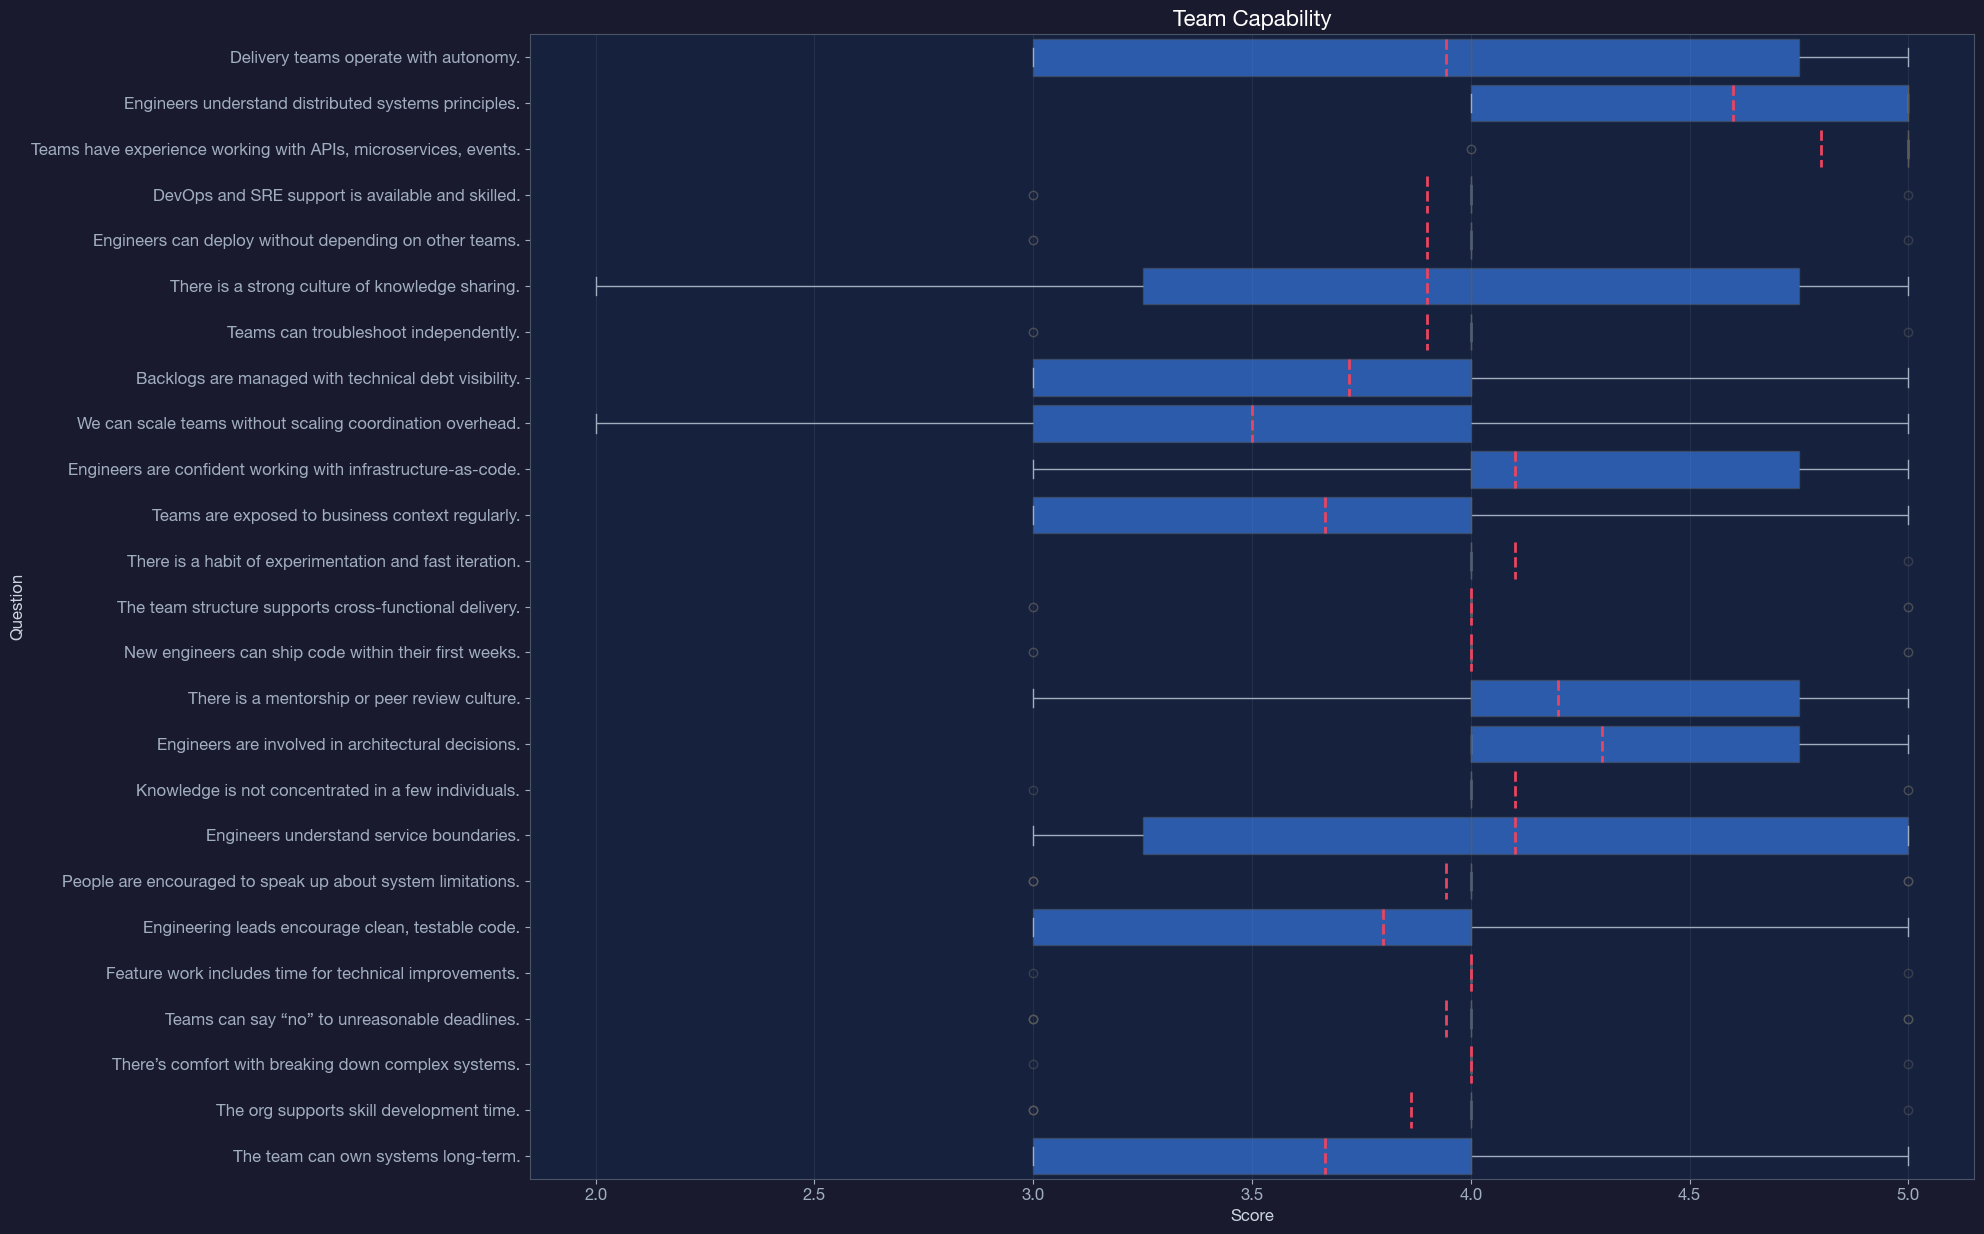

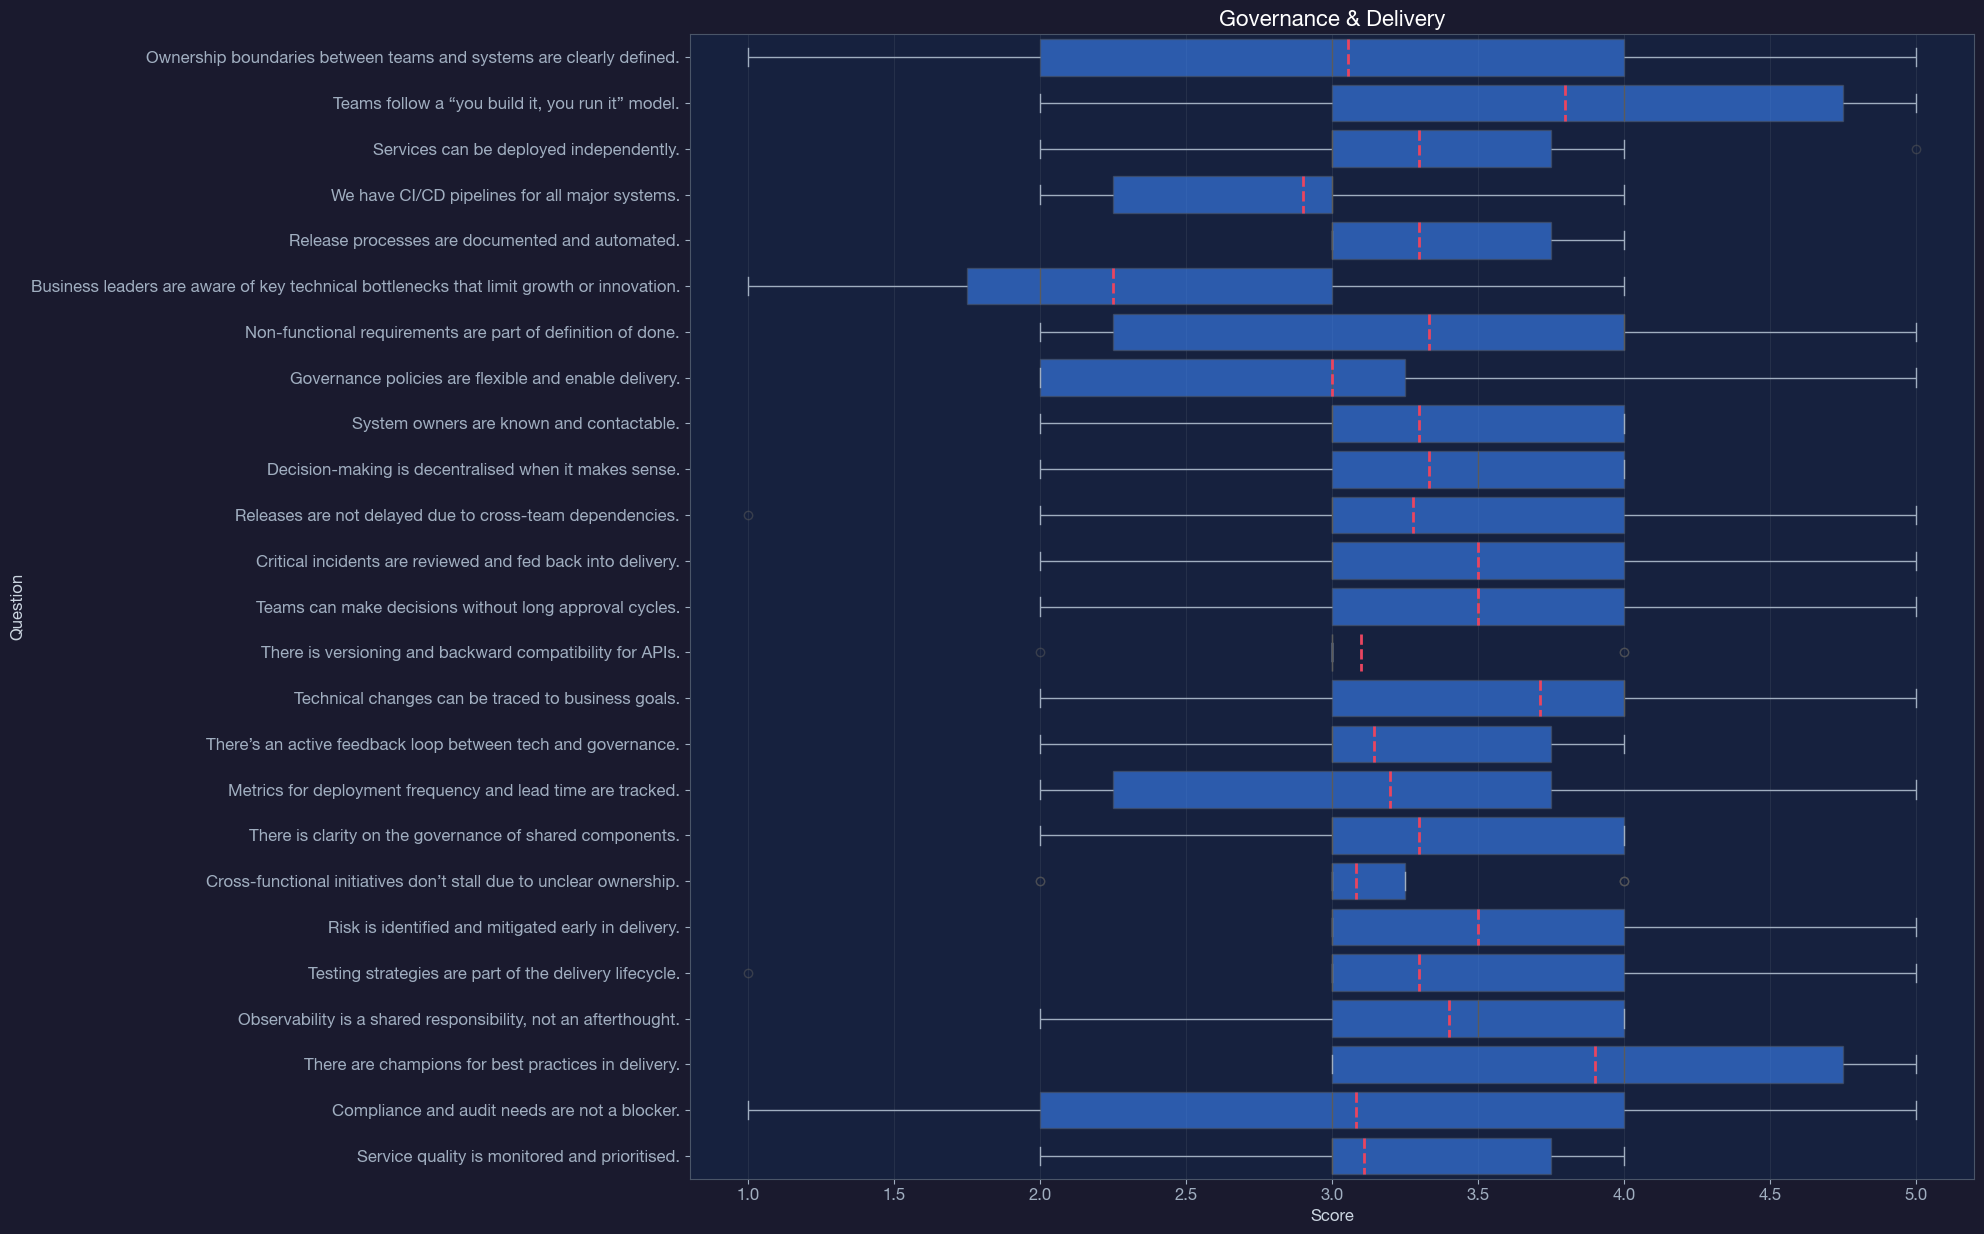

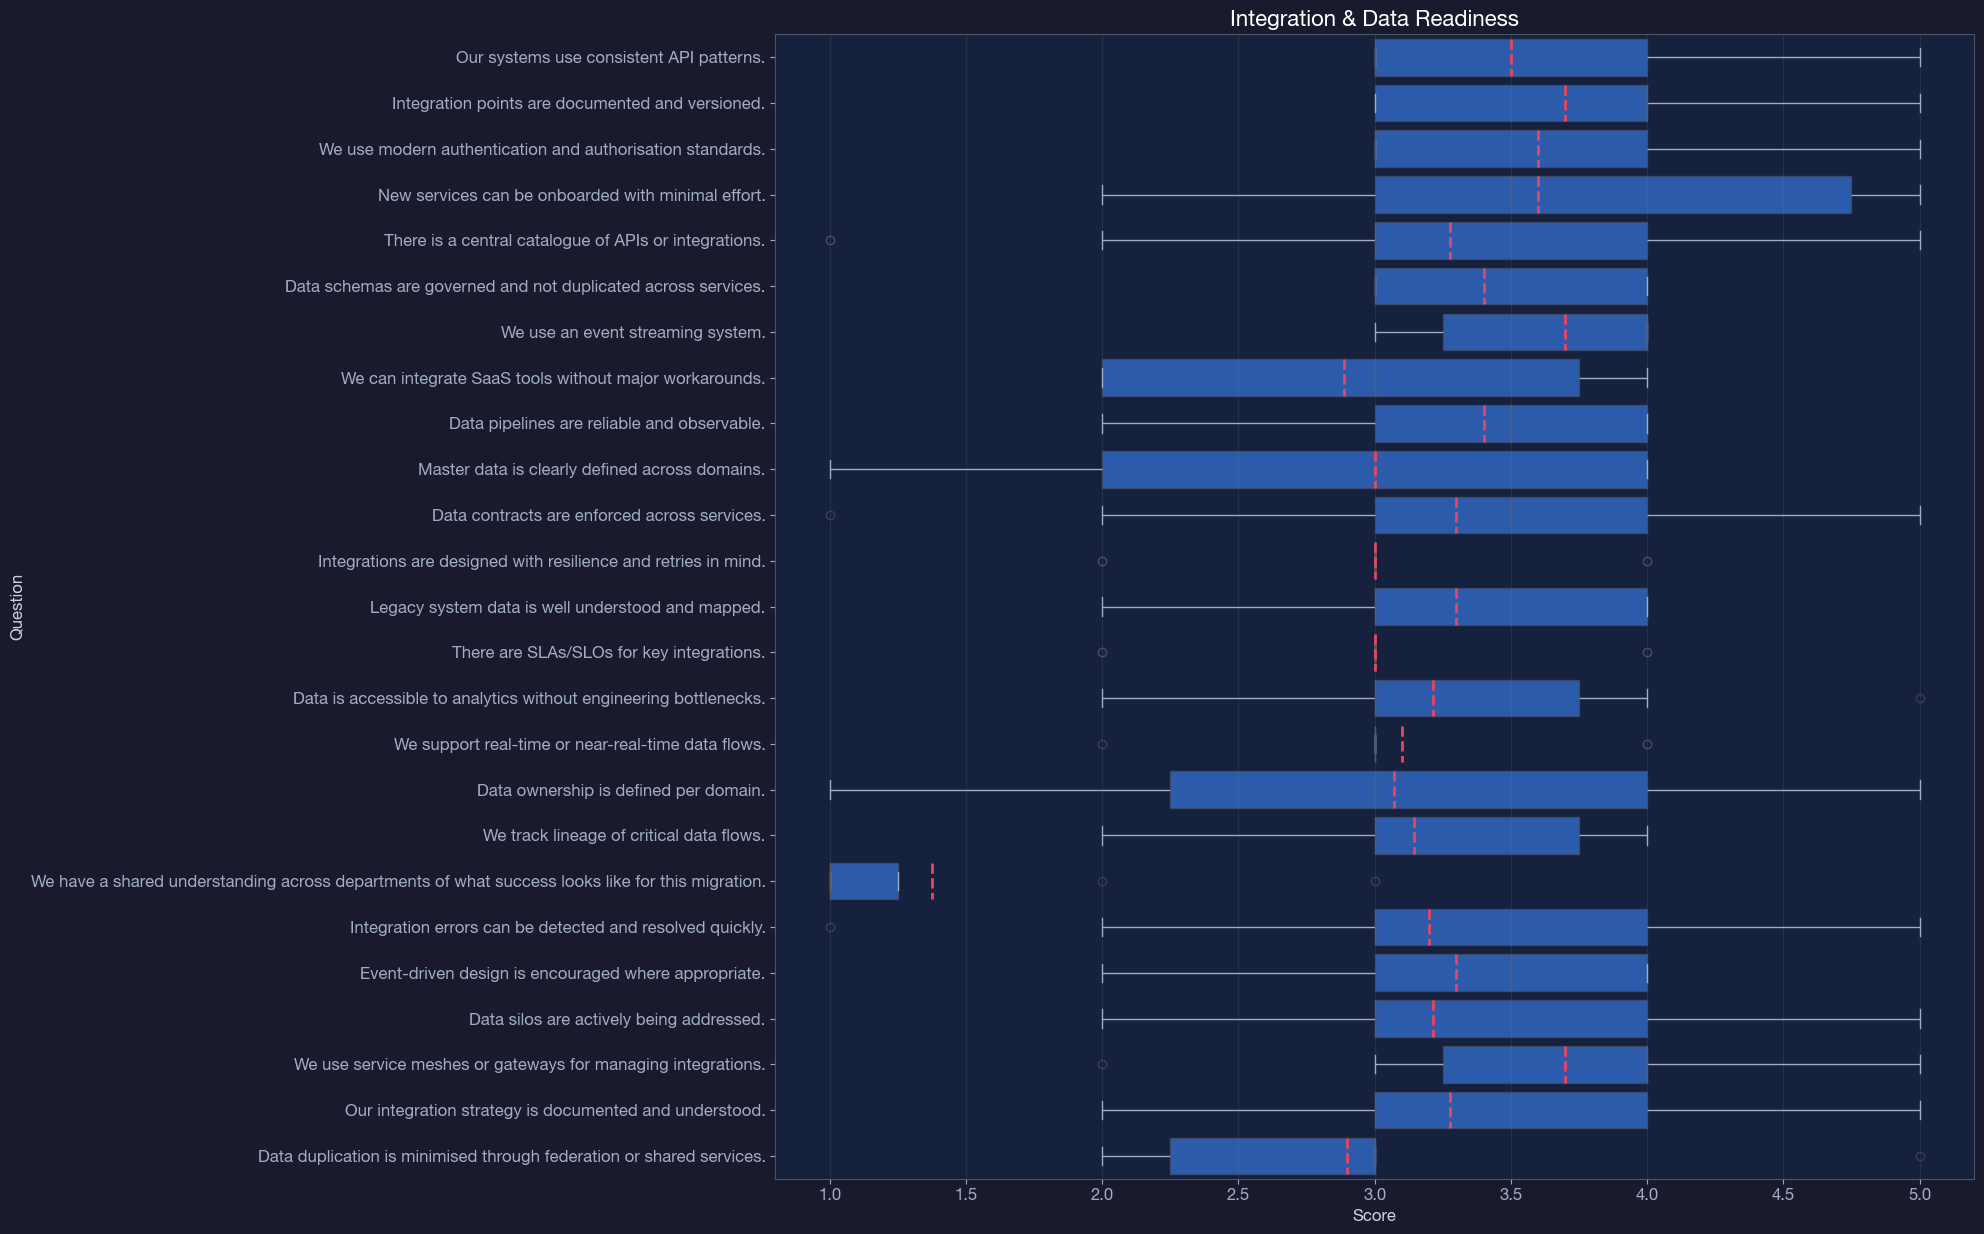

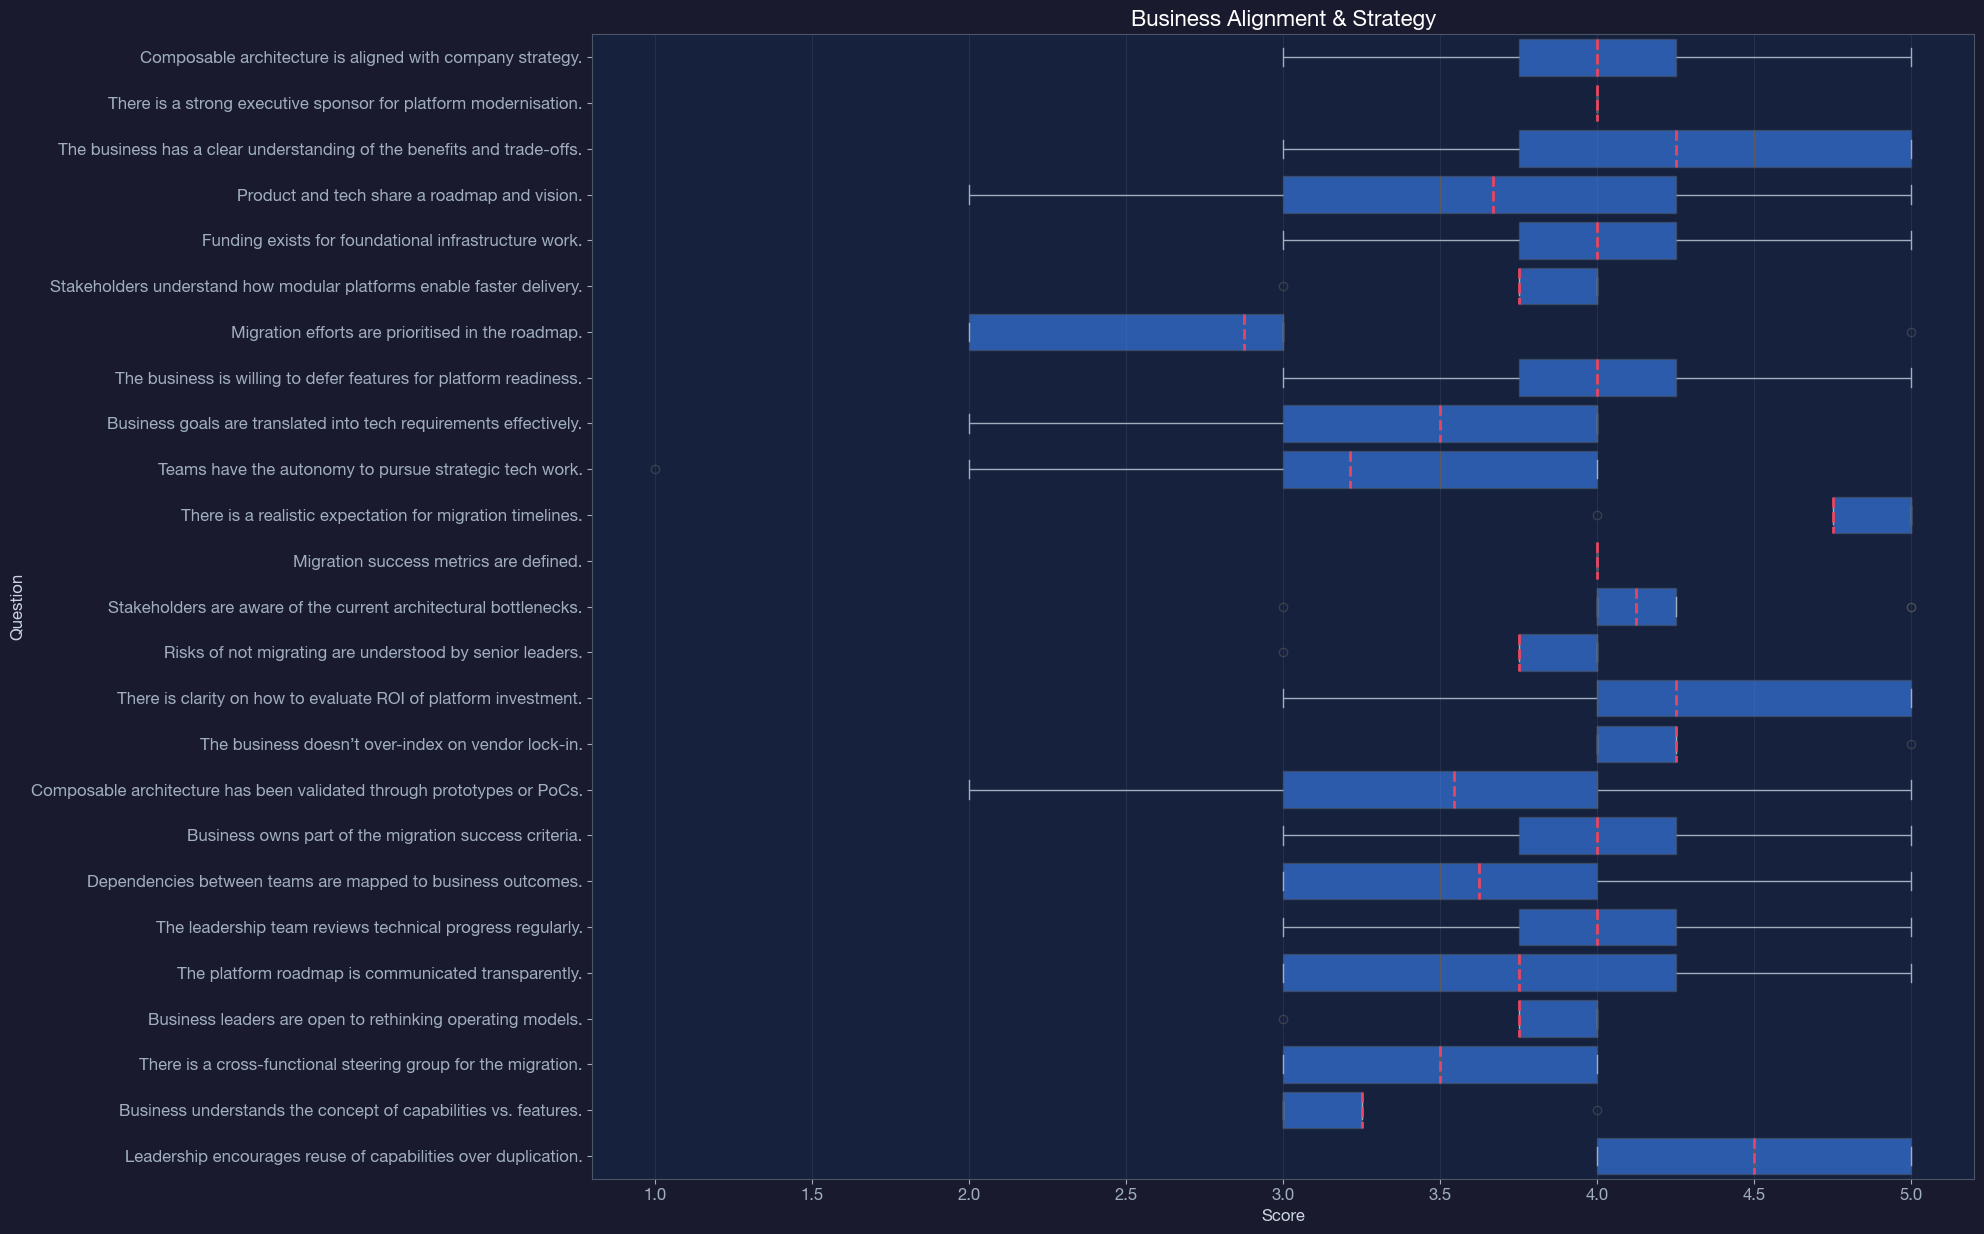

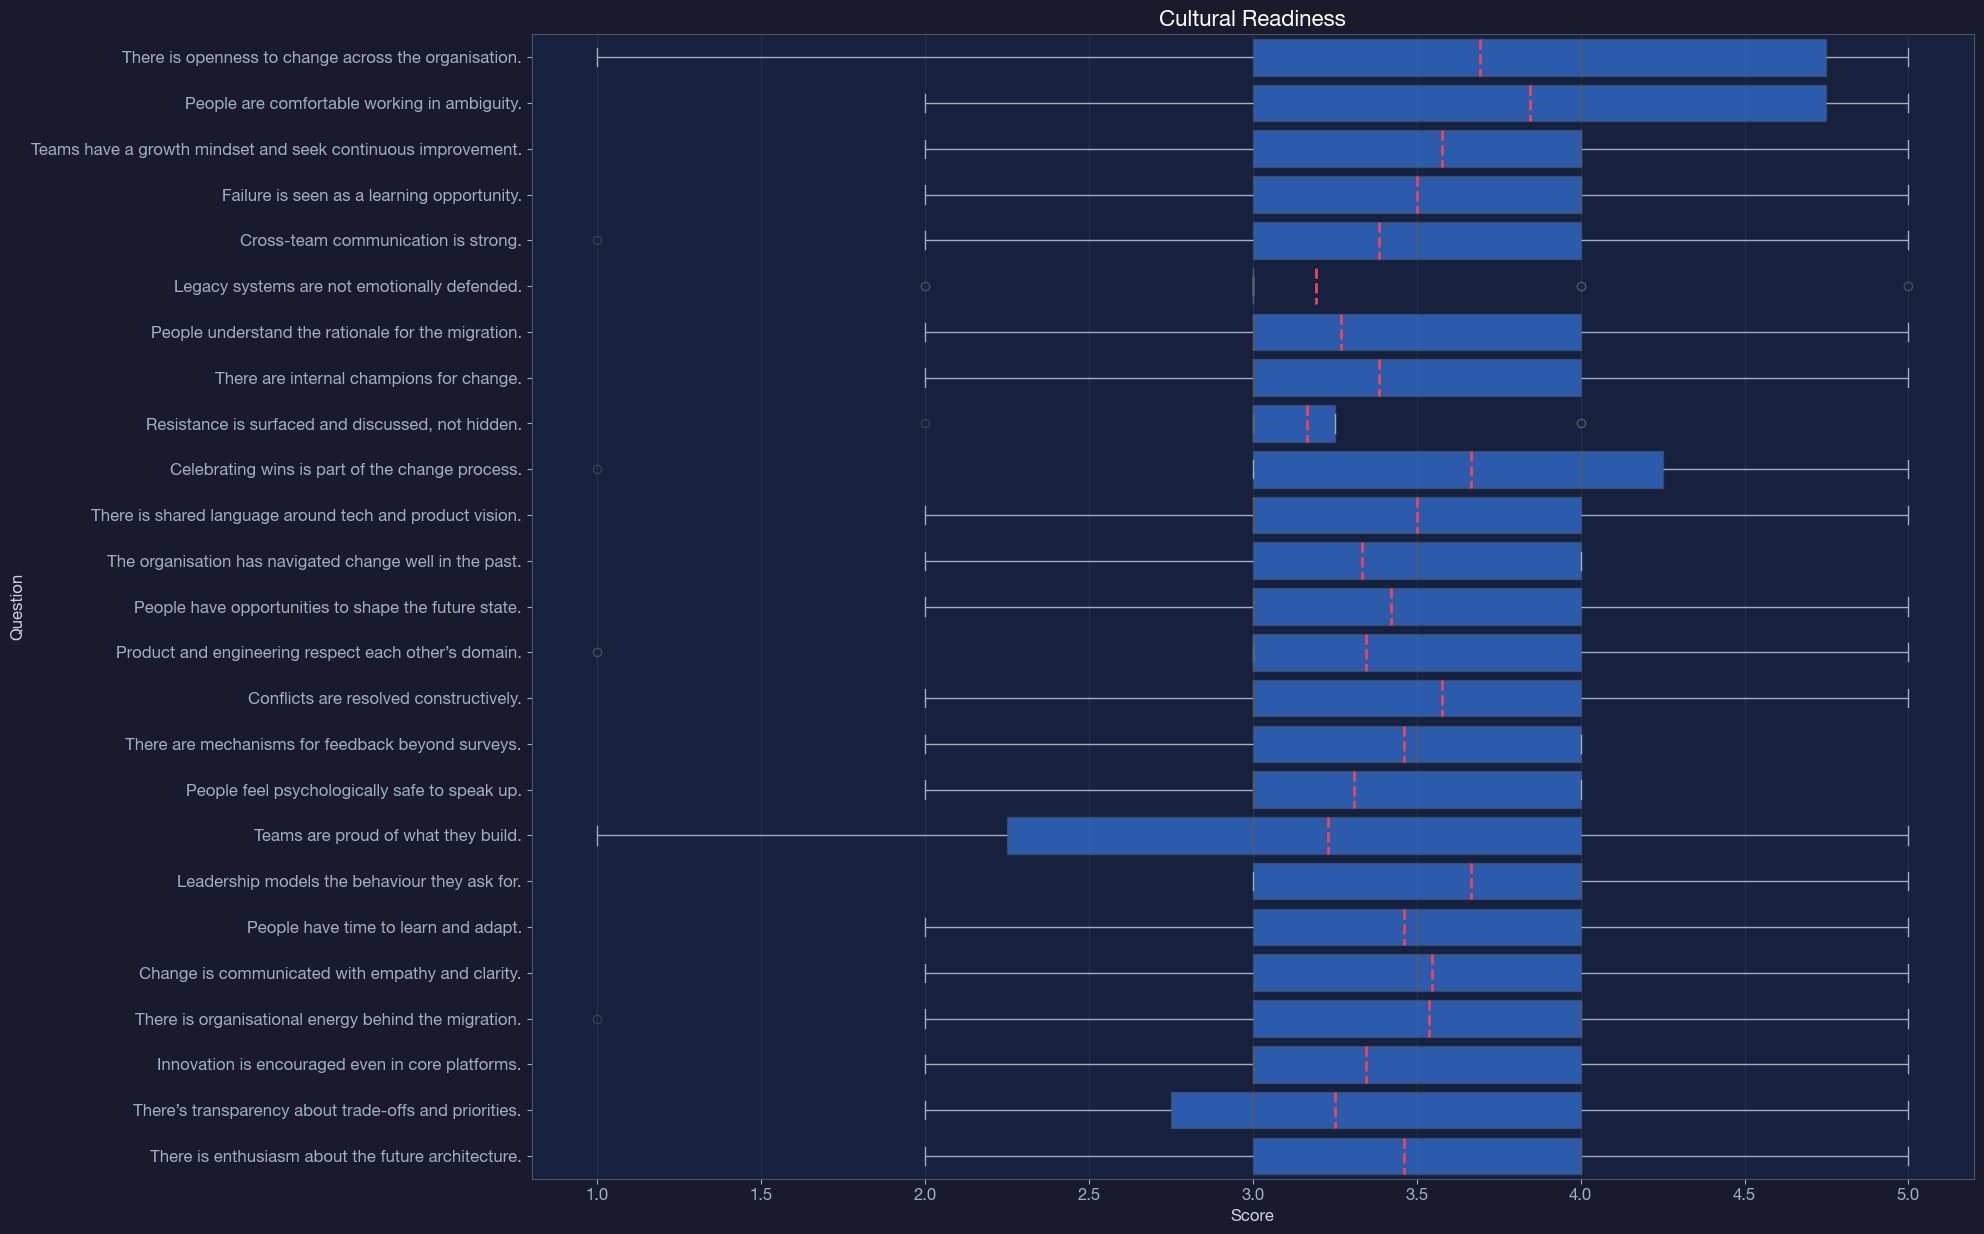

In [25]:
# Group questions by their domain
domains = questionnaire['Category'].unique()

# Iterate through each domain
for domain in domains:
    # Filter questions belonging to the current domain
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    valid_domain_question_ids = [qid for qid in domain_question_ids if qid in combined_quantitative_df.columns]
    
    # Filter the quantitative data for the current domain's questions
    domain_data = combined_quantitative_df[valid_domain_question_ids].replace(0, np.nan)
    
    # Map question IDs to their full text
    question_text_mapping = questionnaire['Question'].to_dict()
    domain_data.rename(columns=question_text_mapping, inplace=True)
    
    # Melt the DataFrame to long format for seaborn boxplot
    melted_data = domain_data.melt(var_name='Question', value_name='Score')
    
    # Calculate the number of unique questions
    num_questions = len(melted_data['Question'].unique())
    
    # Create the boxplot
    plt.figure(figsize=(20, num_questions * 0.5))  # Adjust height dynamically based on the number of questions
    sns.boxplot(data=melted_data, y='Question', x='Score', orient='h', showmeans=True, meanline=True,
                meanprops={"color": "#e94560", "linestyle": "--", "linewidth": 2},
                boxprops={"facecolor": "#3b82f6", "edgecolor": _GRID_GRAY, "alpha": 0.6},
                whiskerprops={"color": _TEXT_MID},
                capprops={"color": _TEXT_MID},
                flierprops={"marker": "o", "color": _TEXT_DIM, "alpha": 0.5})
    
    # Set plot labels and title
    plt.title(f"{domain}", fontsize=16)
    plt.xlabel("Score", fontsize=12)
    plt.ylabel("Question", fontsize=12)
    plt.tight_layout()
    plt.show()

### Confidence Interval of the Responses by Domain

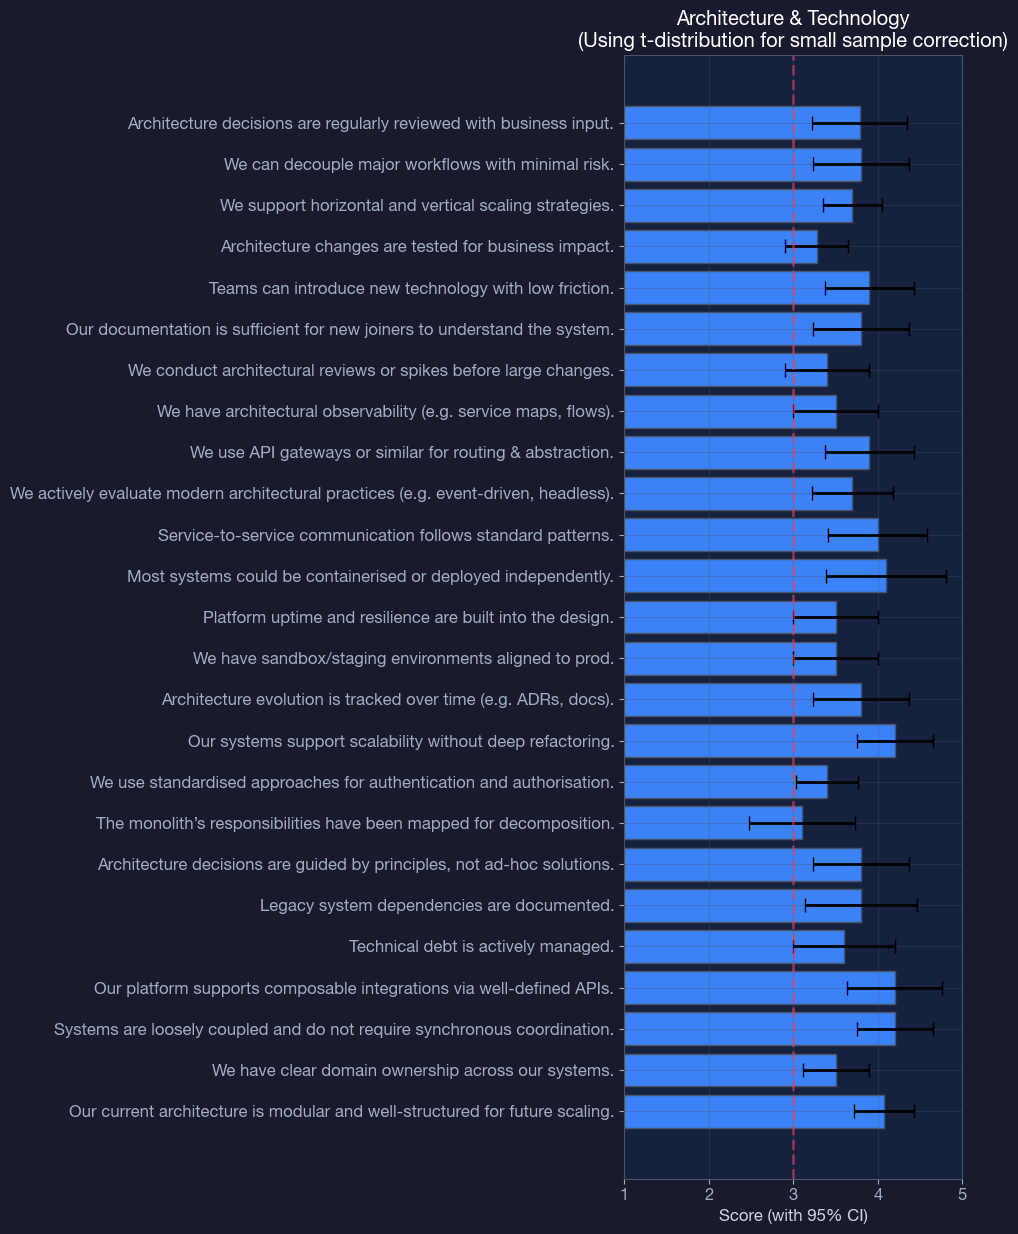

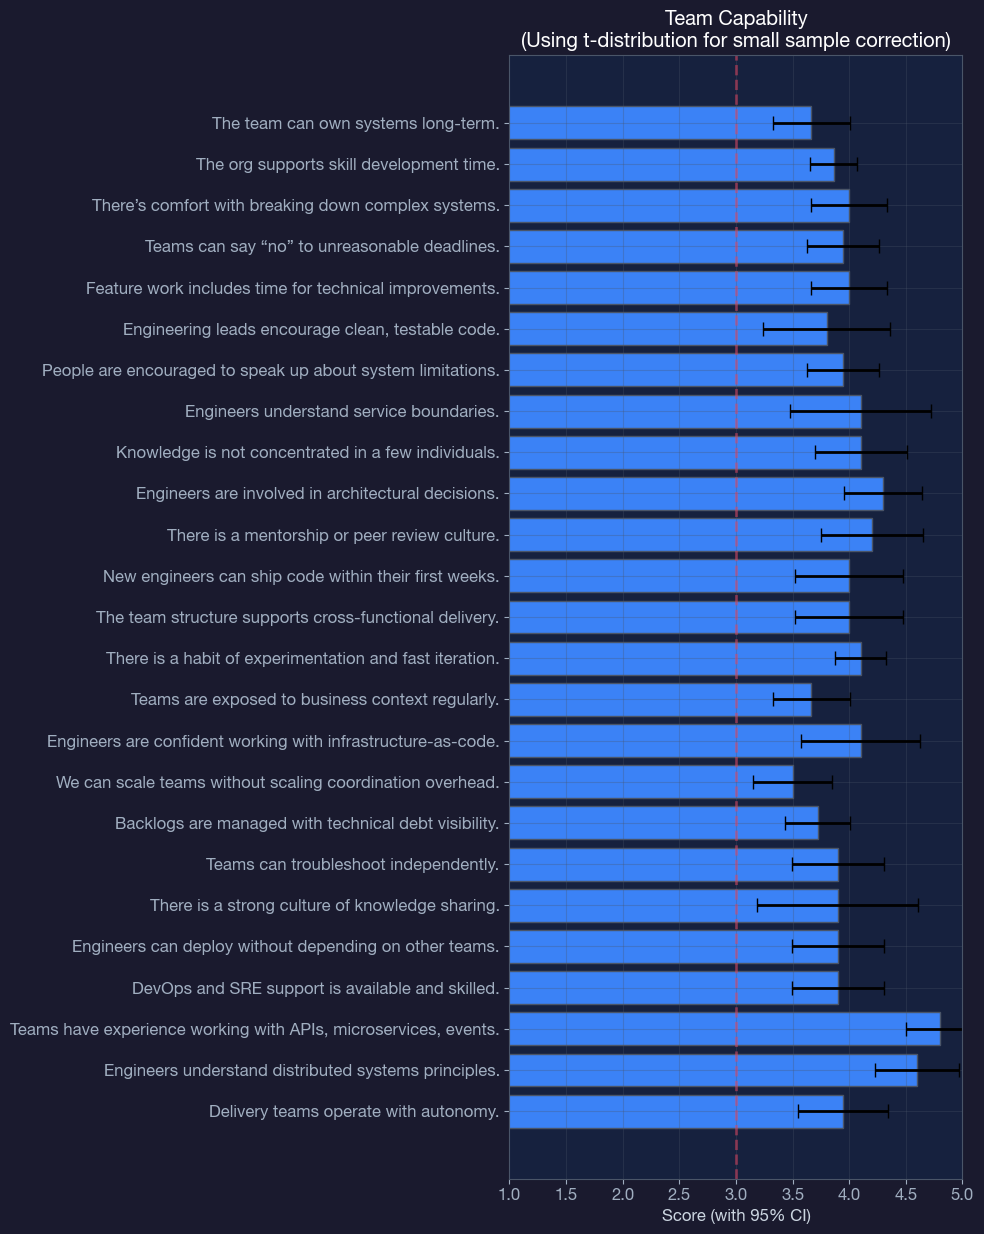

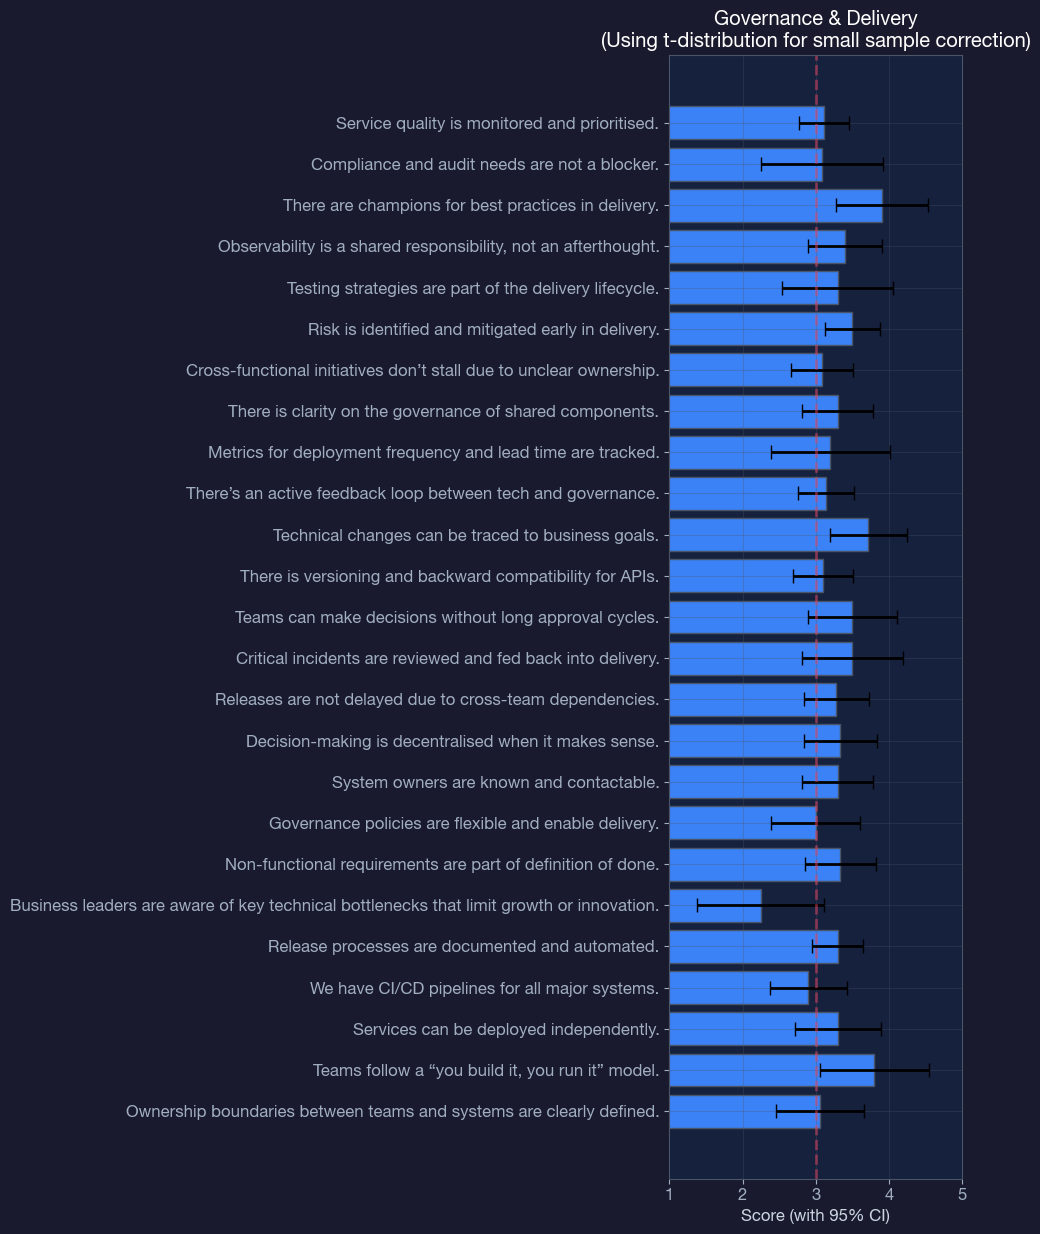

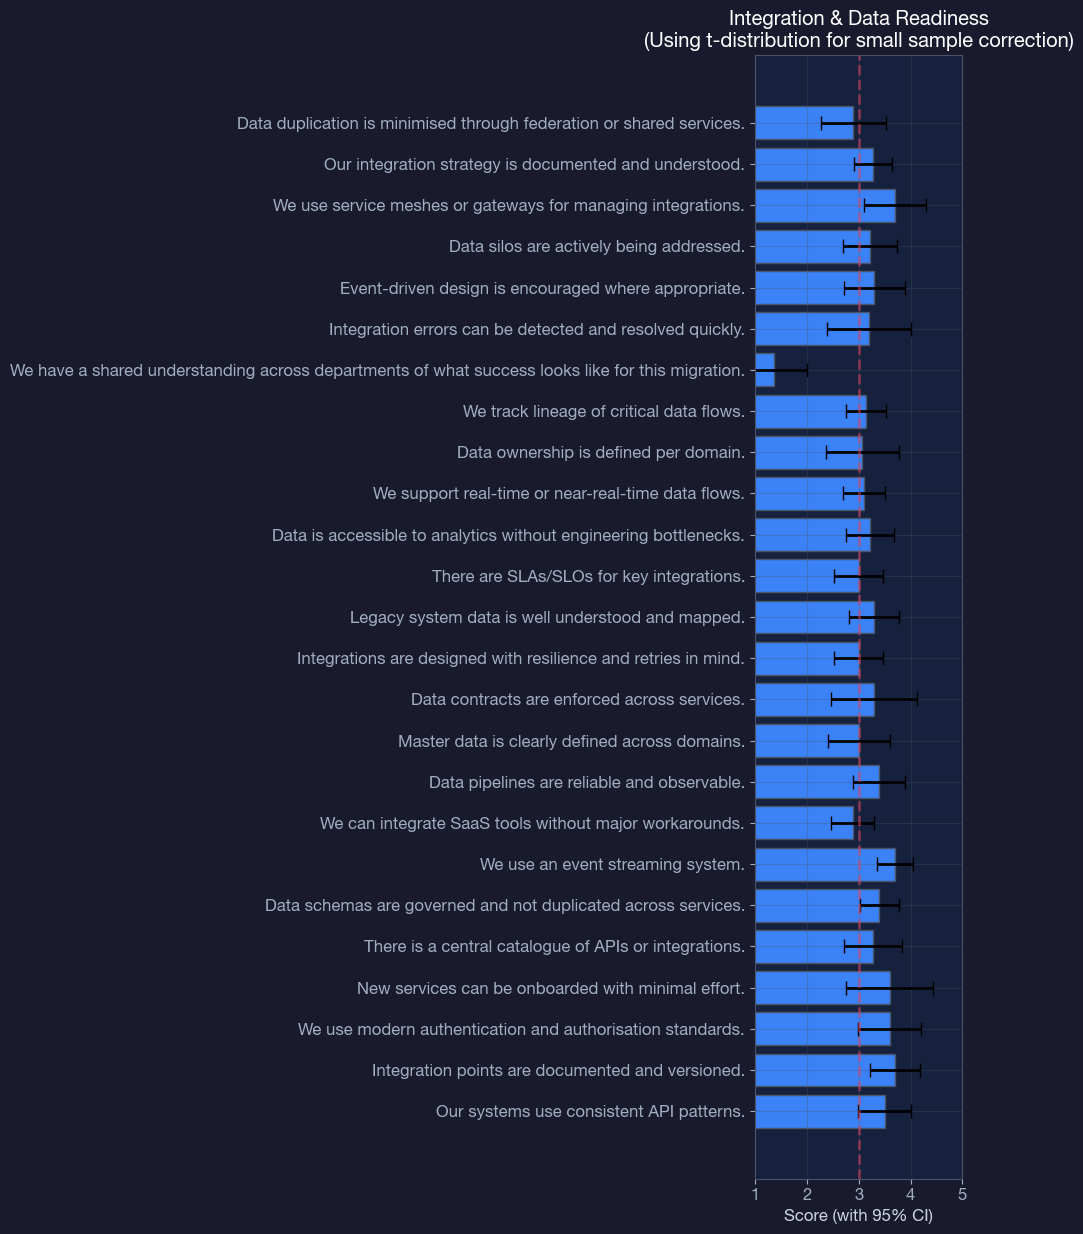

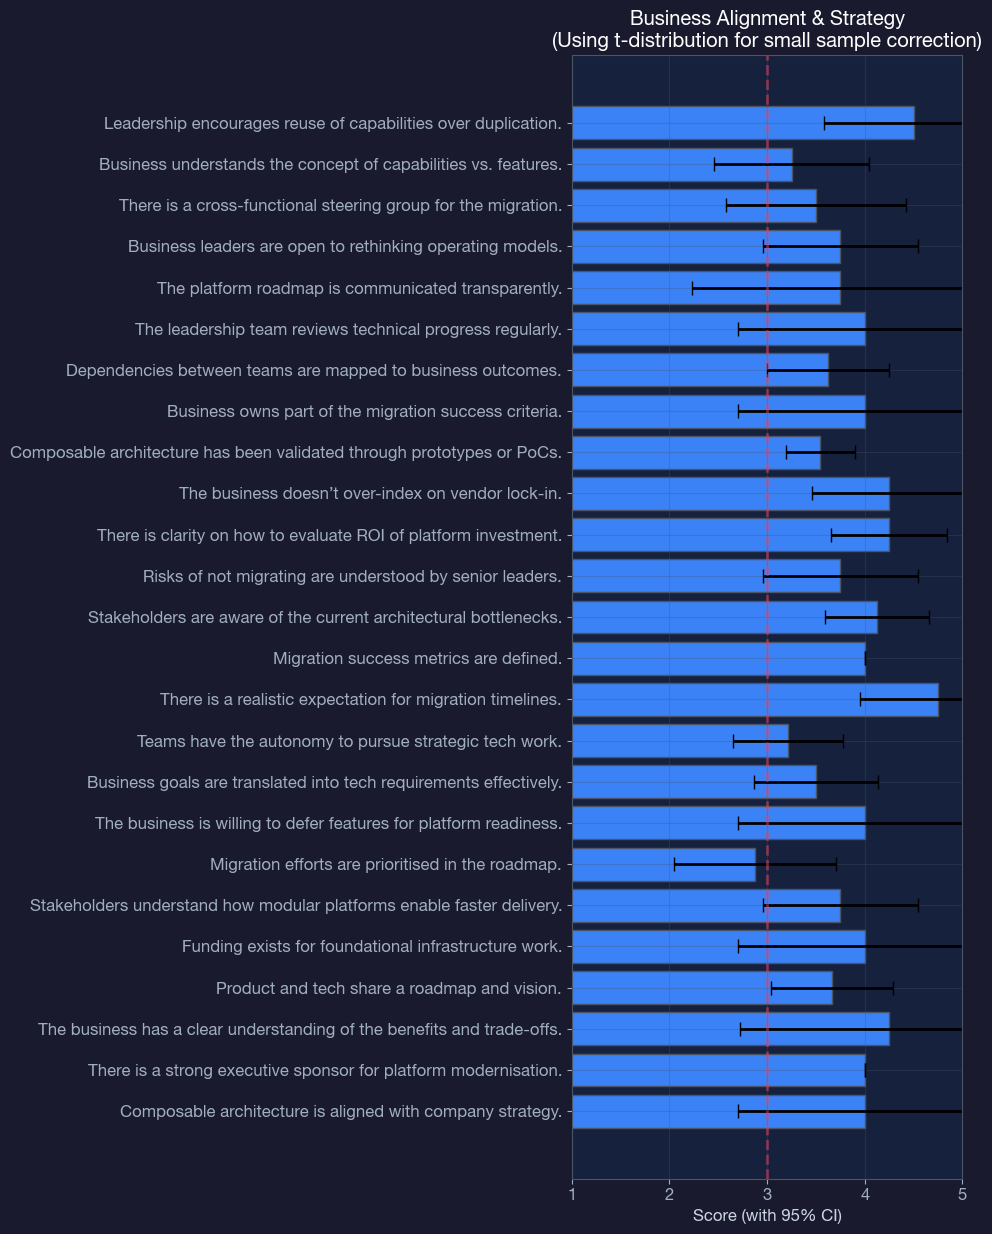

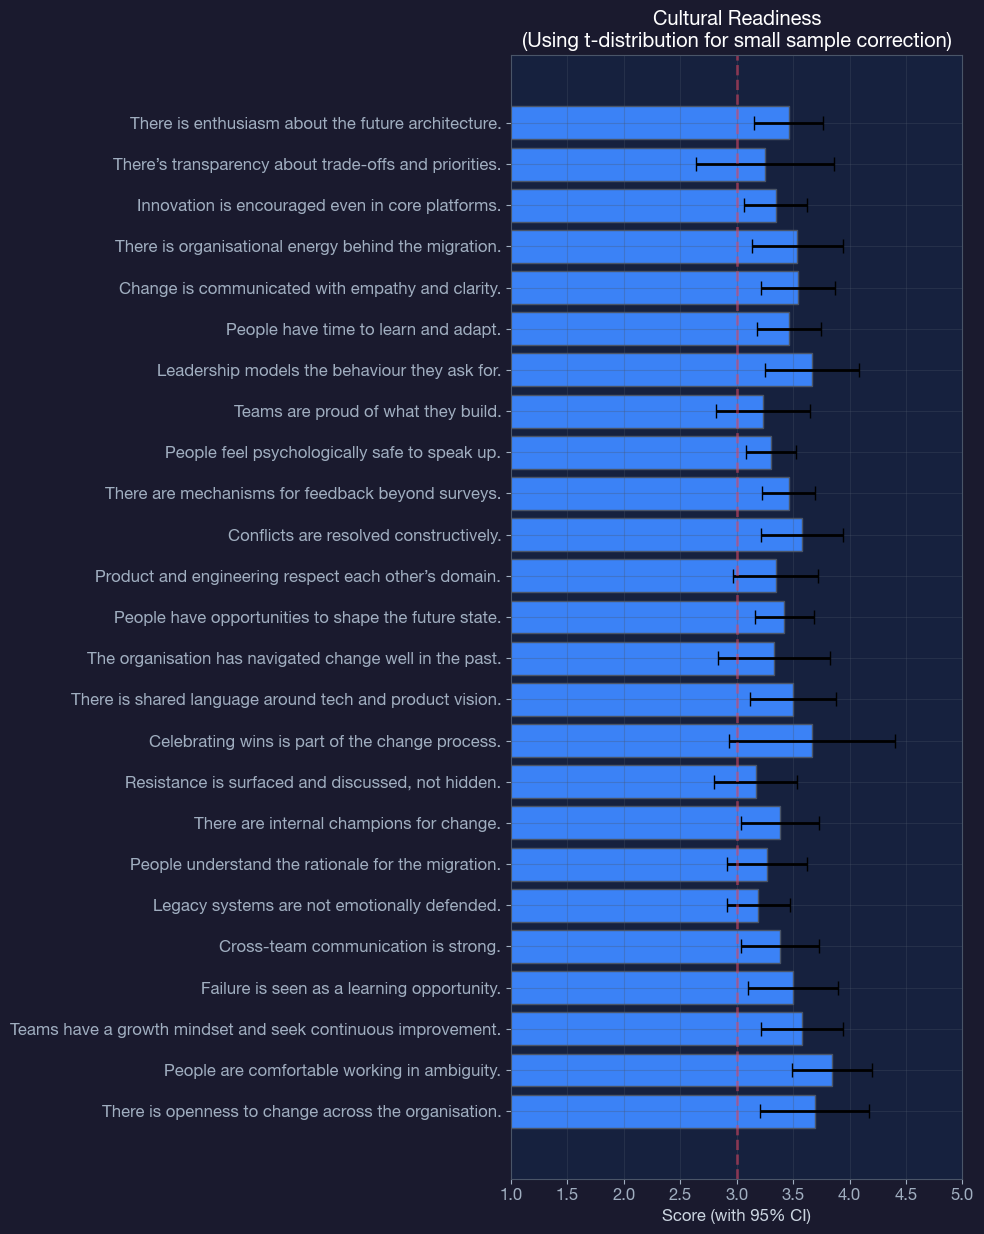

In [26]:
# =============================================================================
# Confidence Interval Analysis (Improved)
# =============================================================================
# Changes from original:
# 1. Using t-distribution critical value for small samples (was z=1.96)
# 2. Added bootstrap CI option for robustness

domains = questionnaire['Category'].unique()

for domain in domains:
    domain_question_ids = questionnaire[questionnaire['Category'] == domain].index
    valid_domain_question_ids = [qid for qid in domain_question_ids if qid in combined_quantitative_df.columns]
    
    domain_data = combined_quantitative_df[valid_domain_question_ids].replace(0, np.nan)
    question_text_mapping = questionnaire['Question'].to_dict()
    domain_data.rename(columns=question_text_mapping, inplace=True)
    
    # Calculate confidence intervals using t-distribution (correct for small samples)
    ci_data = []
    for question in domain_data.columns:
        scores = domain_data[question].dropna()
        n = len(scores)
        if n > 1:
            mean = scores.mean()
            sem = scores.sem()
            
            # Use t-distribution critical value (more accurate for small samples)
            # Original code used z=1.96 which assumes large samples
            t_critical = t_dist.ppf(0.975, df=n-1)  # 95% CI, two-tailed
            ci = t_critical * sem
            
            # Also calculate bootstrap CI for comparison
            _, boot_lower, boot_upper = bootstrap_ci(scores.values)
            
            ci_data.append({
                'question': question,
                'mean': mean,
                'ci_lower_t': mean - ci,
                'ci_upper_t': mean + ci,
                'ci_lower_boot': boot_lower,
                'ci_upper_boot': boot_upper,
                'n': n,
                't_critical': t_critical
            })
    
    if not ci_data:
        continue
    
    ci_df = pd.DataFrame(ci_data)
    
    # Plot with t-distribution CI (more accurate)
    questions = ci_df['question'].tolist()
    means = ci_df['mean'].tolist()
    errors = [(ci_df['ci_upper_t'] - ci_df['ci_lower_t']) / 2].tolist()[0] if len(ci_df) == 1 else \
             ((ci_df['ci_upper_t'] - ci_df['ci_lower_t']) / 2).tolist()
    
    plt.figure(figsize=(10, len(questions) * 0.5))
    plt.barh(questions, means, xerr=errors if isinstance(errors, list) else [errors], 
             color='#3b82f6', edgecolor=_GRID_GRAY, capsize=5)
    
    # Add reference line at neutral (3.0)
    plt.axvline(x=3.0, color='#e94560', linestyle='--', alpha=0.5, label='Neutral')
    
    plt.xlabel("Score (with 95% CI)")
    plt.title(f"{domain}\n(Using t-distribution for small sample correction)")
    plt.xlim(1, 5)
    plt.tight_layout()
    plt.show()

### Critical questions dragging scores down

In [27]:
# Filter for critical questions
critical_question_ids = questionnaire[questionnaire['Critical']].index

# Filter the quantitative data for critical questions
critical_data = combined_quantitative_df[critical_question_ids]

# Calculate the average score for each critical question excluding NaN and 0 values
critical_question_averages = critical_data[critical_data > 0].mean(axis=0)

# Identify critical questions with low average scores
low_scoring_critical_questions = critical_question_averages[critical_question_averages < threshold_confidence_low]

# Map question IDs to their text
low_scoring_critical_questions_text = questionnaire.loc[low_scoring_critical_questions.index, 'Question']
                                                        
# Print the results
print("Critical Questions Dragging Scores Down:")
for question_id, score in low_scoring_critical_questions.items():
    print(f"ID: {question_id}, Score: {score:.2f}, Question: {low_scoring_critical_questions_text[question_id]}")

Critical Questions Dragging Scores Down:
ID: 56, Score: 2.25, Question: Business leaders are aware of key technical bottlenecks that limit growth or innovation.
ID: 94, Score: 1.38, Question: We have a shared understanding across departments of what success looks like for this migration.
ID: 107, Score: 2.88, Question: Migration efforts are prioritised in the roadmap.


### Non critical questions, which have low results

In [28]:

# Percentage of participants who had to answer for a question to be considered relevant
threshold_valid_percentage = 0.50

# Filter for non-critical questions
non_critical_question_ids = questionnaire[~questionnaire['Critical']].index

# Filter the quantitative data for non-critical questions
non_critical_data = combined_quantitative_df[non_critical_question_ids.intersection(combined_quantitative_df.columns)]

# Calculate the average score for each non-critical question excluding NaN and 0 values
non_critical_question_averages = non_critical_data[non_critical_data > 0].mean(axis=0)

# Identify non critical questions with low average scores
low_scoring_non_critical_questions = non_critical_question_averages[non_critical_question_averages < threshold_confidence_low]

# Validate if the question was answered by at least 60% of all participants
valid_question_ids = non_critical_data.columns[(non_critical_data > 0).sum() >= (len(non_critical_data) * threshold_valid_percentage)]
low_scoring_non_critical_questions = low_scoring_non_critical_questions[low_scoring_non_critical_questions.index.isin(valid_question_ids)]

# Map question IDs to their text
low_scoring_non_critical_questions_text = questionnaire.loc[low_scoring_non_critical_questions.index, 'Question']

# Print the results
print(f"Non-Critical Questions Dragging Scores Down (excluding questions answered by less than {threshold_valid_percentage * 100}% of participants):")
for question_id, score in low_scoring_non_critical_questions.items():
    print(f"ID: {question_id}, Score: {score:.2f}, Question: {low_scoring_non_critical_questions_text[question_id]}, Responses: {(non_critical_data[question_id] > 0).sum()}")

Non-Critical Questions Dragging Scores Down (excluding questions answered by less than 50.0% of participants):
ID: 83, Score: 2.89, Question: We can integrate SaaS tools without major workarounds., Responses: 18


### Questions per role dragging down the score

In [29]:
# Initialize a dictionary to store the lowest scoring questions for each role
lowest_scoring_questions_by_role = {}

# Iterate through each role
for role in role_sentiments.keys():
    # Filter the quantitative data for the current role
    role_data = combined_quantitative_df[combined_quantitative_df['role'] == role].drop('role', axis=1)
    
    # Calculate the average score for each question
    question_averages = role_data[role_data > 0].mean(axis=0)
    
    # Identify the lowest scoring questions (e.g., below the threshold_confidence_low)
    low_scoring_questions = question_averages[question_averages < threshold_confidence_low]
    
    # Map question IDs to their text
    low_scoring_questions_text = questionnaire.loc[low_scoring_questions.index, 'Question']
    
    # Store the results in the dictionary
    lowest_scoring_questions_by_role[role] = list(zip(low_scoring_questions_text, low_scoring_questions))

# Print the lowest scoring questions for each role
for role, questions in lowest_scoring_questions_by_role.items():
    print(f"Lowest Scoring Questions for {role}:")
    for question, score in questions:
        print(f"  Question: {question}, Score: {score:.2f}")
    print("\n")

Lowest Scoring Questions for Engineering:
  Question: We have CI/CD pipelines for all major systems., Score: 2.90
  Question: Data duplication is minimised through federation or shared services., Score: 2.90
  Question: Teams have the autonomy to pursue strategic tech work., Score: 2.90


Lowest Scoring Questions for Product:
  Question: Architecture changes are tested for business impact., Score: 2.88
  Question: Ownership boundaries between teams and systems are clearly defined., Score: 2.38
  Question: Governance policies are flexible and enable delivery., Score: 2.88
  Question: Compliance and audit needs are not a blocker., Score: 2.88
  Question: Service quality is monitored and prioritised., Score: 2.88
  Question: We can integrate SaaS tools without major workarounds., Score: 2.38
  Question: Migration efforts are prioritised in the roadmap., Score: 2.88
  Question: Teams are proud of what they build., Score: 2.88


Lowest Scoring Questions for Business:
  Question: Business le

### Statistically insignificant questions

In [30]:
# =============================================================================
# Statistical Significance Analysis (Improved)
# =============================================================================
# Changes from original:
# 1. Added effect size (Cohen's d) calculation for all tests
# 2. Added non-parametric alternative (Wilcoxon signed-rank)
# 3. Added multiple comparison correction (Benjamini-Hochberg FDR)
# 4. Added practical significance assessment

alpha = threshold_statistical_significance

# Store comprehensive results
statistical_results = []

for question in combined_quantitative_df.columns:
    if question == 'role':
        continue
        
    scores = combined_quantitative_df[question].replace(0, np.nan).dropna()
    
    if len(scores) < 3:
        continue
    
    result = {
        'question_id': question,
        'question_text': questionnaire.loc[question, 'Question'] if question in questionnaire.index else str(question),
        'n': len(scores),
        'mean': scores.mean(),
        'std': scores.std(),
        'median': scores.median()
    }
    
    # Parametric test (t-test)
    t_stat, t_pval = ttest_1samp(scores, 3)
    result['t_statistic'] = t_stat
    result['t_pvalue'] = t_pval
    
    # Non-parametric test (Wilcoxon signed-rank)
    try:
        centered = scores - 3
        non_zero = centered[centered != 0]
        if len(non_zero) >= 3:
            w_stat, w_pval = wilcoxon(non_zero, alternative='two-sided')
            result['wilcoxon_pvalue'] = w_pval
        else:
            result['wilcoxon_pvalue'] = np.nan
    except:
        result['wilcoxon_pvalue'] = np.nan
    
    # Effect size (Cohen's d)
    d = cohens_d_one_sample(scores.values, 3.0)
    result['cohens_d'] = d
    result['effect_interpretation'] = interpret_effect_size(d)
    
    # Practical significance
    result['practical_significance'] = abs(scores.mean() - 3) >= PRACTICAL_SIGNIFICANCE_THRESHOLD
    
    statistical_results.append(result)

# Convert to DataFrame
stats_df = pd.DataFrame(statistical_results)

# Apply multiple comparison correction (Benjamini-Hochberg)
if len(stats_df) > 0:
    _, stats_df['t_pvalue_corrected'], _, _ = multipletests(
        stats_df['t_pvalue'].fillna(1).values, 
        method='fdr_bh'
    )

# Identify significant results (using corrected p-values)
significant_results = stats_df[stats_df['t_pvalue_corrected'] < alpha]
not_significant = stats_df[stats_df['t_pvalue_corrected'] >= alpha]

# Print summary
print("=" * 70)
print("STATISTICAL SIGNIFICANCE ANALYSIS")
print("=" * 70)
print(f"\nTotal questions analysed: {len(stats_df)}")
print(f"Statistically significant (corrected p < {alpha}): {len(significant_results)}")
print(f"Not statistically significant: {len(not_significant)}")

# Show questions that are both statistically AND practically significant
key_findings = stats_df[
    (stats_df['t_pvalue_corrected'] < alpha) & 
    (stats_df['practical_significance'] == True)
].sort_values('cohens_d', key=abs, ascending=False)

print(f"\n{'='*70}")
print("KEY FINDINGS (Statistically + Practically Significant)")
print("="*70)
for _, row in key_findings.head(10).iterrows():
    direction = "ABOVE" if row['mean'] > 3 else "BELOW"
    print(f"\n{row['question_text'][:70]}...")
    print(f"  Mean: {row['mean']:.2f} ({direction} neutral) | Effect: {row['effect_interpretation']} (d={row['cohens_d']:.2f})")

# Print not significant questions
print(f"\n{'='*70}")
print("NOT STATISTICALLY SIGNIFICANT (may need more responses)")
print("="*70)
for _, row in not_significant.head(10).iterrows():
    print(f"  {row['question_text'][:60]}... (p={row['t_pvalue_corrected']:.3f})")

STATISTICAL SIGNIFICANCE ANALYSIS

Total questions analysed: 150
Statistically significant (corrected p < 0.05): 71
Not statistically significant: 79

KEY FINDINGS (Statistically + Practically Significant)

Teams have experience working with APIs, microservices, events....
  Mean: 4.80 (ABOVE neutral) | Effect: large (d=4.27)

There is a realistic expectation for migration timelines....
  Mean: 4.75 (ABOVE neutral) | Effect: large (d=3.50)

There is a habit of experimentation and fast iteration....
  Mean: 4.10 (ABOVE neutral) | Effect: large (d=3.48)

Engineers understand distributed systems principles....
  Mean: 4.60 (ABOVE neutral) | Effect: large (d=3.10)

Engineers are involved in architectural decisions....
  Mean: 4.30 (ABOVE neutral) | Effect: large (d=2.69)

Leadership encourages reuse of capabilities over duplication....
  Mean: 4.50 (ABOVE neutral) | Effect: large (d=2.60)

The business doesn’t over-index on vendor lock-in....
  Mean: 4.25 (ABOVE neutral) | Effect: large (d

/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


### Power analysis 

Test for sample size necessary to achieve statistical significance.

In [31]:
# =============================================================================
# Power Analysis (Corrected)
# =============================================================================
# Changes from original:
# 1. Using TTestPower (one-sample) instead of TTestIndPower (two-sample)
# 2. Using conventional power of 0.80 instead of 0.95
# 3. Added achieved power calculation for all tests

# Initialize the CORRECT power analysis object for one-sample t-test
analysis = TTestPower()

# Dictionary to store power analysis results
power_analysis_results = {}

# Analyse all questions (not just non-significant ones)
for _, row in stats_df.iterrows():
    question = row['question_id']
    
    if np.isnan(row['cohens_d']) or row['cohens_d'] == 0:
        continue
    
    effect_size = abs(row['cohens_d'])
    n = row['n']
    
    try:
        # Calculate achieved power with current sample size
        achieved_power = analysis.solve_power(
            effect_size=effect_size,
            nobs=n,
            alpha=alpha,
            alternative='two-sided'
        )
        
        # Calculate required sample size for desired power (0.80)
        required_n = analysis.solve_power(
            effect_size=effect_size,
            power=desired_power,
            alpha=alpha,
            alternative='two-sided'
        )
        
        power_analysis_results[question] = {
            'Question': row['question_text'][:50],
            'Effect Size (d)': round(effect_size, 3),
            'Effect Interpretation': row['effect_interpretation'],
            'Current N': n,
            'Achieved Power': round(achieved_power, 2),
            'Required N (power=0.80)': int(np.ceil(required_n)),
            'Adequately Powered': achieved_power >= desired_power
        }
    except Exception as e:
        continue

# Convert to DataFrame for display
power_df = pd.DataFrame(power_analysis_results).T

# Summary statistics
n_underpowered = len(power_df[power_df['Adequately Powered'] == False])
n_adequately_powered = len(power_df[power_df['Adequately Powered'] == True])

print("=" * 70)
print("POWER ANALYSIS SUMMARY")
print("=" * 70)
print(f"\nDesired power level: {desired_power}")
print(f"Adequately powered tests: {n_adequately_powered}")
print(f"Underpowered tests: {n_underpowered}")

# Show underpowered tests that need more responses
underpowered = power_df[power_df['Adequately Powered'] == False].sort_values('Required N (power=0.80)')

print(f"\n{'='*70}")
print("UNDERPOWERED TESTS (need more responses)")
print("="*70)
print(f"{'Question':<50} {'Current N':>10} {'Need N':>10} {'Power':>8}")
print("-" * 80)

for idx, row in underpowered.head(15).iterrows():
    shortfall = row['Required N (power=0.80)'] - row['Current N']
    print(f"{row['Question']:<50} {row['Current N']:>10} {row['Required N (power=0.80)']:>10} {row['Achieved Power']:>8.2f}")

print(f"\n{'='*70}")
print("WELL-POWERED TESTS (high confidence in results)")
print("="*70)
well_powered = power_df[power_df['Adequately Powered'] == True].sort_values('Achieved Power', ascending=False)
for idx, row in well_powered.head(10).iterrows():
    print(f"  {row['Question']}... (power={row['Achieved Power']:.2f})")

POWER ANALYSIS SUMMARY

Desired power level: 0.8
Adequately powered tests: 58
Underpowered tests: 86

UNDERPOWERED TESTS (need more responses)
Question                                            Current N     Need N    Power
--------------------------------------------------------------------------------
Risks of not migrating are understood by senior le          4          6     0.53
Business leaders are open to rethinking operating           4          6     0.53
Stakeholders understand how modular platforms enab          4          6     0.53
The business has a clear understanding of the bene          4          7     0.44
The leadership team reviews technical progress reg          4          8     0.40
Composable architecture is aligned with company st          4          8     0.40
Business owns part of the migration success criter          4          8     0.40
The business is willing to defer features for plat          4          8     0.40
Funding exists for foundational infras

# Qualitative Analysis

## Latent Dirichlet Allocation (LDA)

### Cleaning up the dataset

In [32]:
# Preprocess the qualitative data
# Combine all responses into a single column for analysis
question_mapping = questionnaire['Question'].to_dict()
mapped_qualitative_df = combined_qualitative_df.rename(columns=question_mapping)
text_data = mapped_qualitative_df.drop(columns=['role']).fillna('').apply(lambda row: ' '.join(row), axis=1)
# Clean the text data
text_data = text_data.str.replace(r'\s+', ' ', regex=True).str.strip()  # Clean up whitespace
text_data = text_data.str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)  # Remove special characters
text_data = text_data.str.lower()  # Convert to lowercase
# Remove unwanted words
text_data = text_data.str.replace(r'\b\w{1,2}\b', '', regex=True)  # Remove short words
text_data = text_data.str.replace(r'\b(?:the|and|is|to|in|of|for|on|a|an)\b', '', regex=True)  # Remove common stop words
text_data = text_data.str.replace(r'\b(?:very|really|just|so|that)\b', '', regex=True)  # Remove filler words
# Pronouns
text_data = text_data.str.replace(r'\b(?:i|me|my|we|us|our)\b', '', regex=True)  # Remove personal pronouns
text_data = text_data.str.replace(r'\b(?:this|these|those|it|its)\b', '', regex=True)  # Remove demonstrative pronouns
text_data = text_data.str.replace(r'\b(?:he|him|his|she|her)\b', '', regex=True)  # Remove gendered pronouns
text_data = text_data.str.replace(r'\b(?:you|your)\b', '', regex=True)  # Remove second-person pronouns
text_data = text_data.str.replace(r'\b(?:there|they|them|their)\b', '', regex=True)  # Remove third-person pronouns
text_data = text_data.str.replace(r'\b(?:who|whom|whose)\b', '', regex=True)  # Remove interrogative pronouns
text_data = text_data.str.replace(r'\b(?:what|which|that)\b', '', regex=True)  # Remove relative pronouns
text_data = text_data.str.replace(r'\b(?:myself|yourself|himself|herself|itself|ourselves|themselves)\b', '', regex=True)  # Remove reflexive pronouns
text_data = text_data.str.replace(r'\b(?:somebody|somebody\'s|someones|someone\'s)\b', '', regex=True)  # Remove indefinite pronouns
text_data = text_data.str.replace(r'\b(?:anybody|anybody\'s|anyones|anyone\'s)\b', '', regex=True)  # Remove indefinite pronouns
text_data = text_data.str.replace(r'\b(?:nobody|nobody\'s|noone|noone\'s)\b', '', regex=True)  # Remove indefinite pronouns
text_data = text_data.str.replace(r'\b(?:each|every|either|neither)\b', '', regex=True)  # Remove distributive pronouns
text_data = text_data.str.replace(r'\b(?:all|both|few|many|several|some)\b', '', regex=True)  # Remove quantifiers
# Conjunctions
text_data = text_data.str.replace(r'\b(?:but|however|although)\b', '', regex=True)  # Remove contrastive conjunctions
text_data = text_data.str.replace(r'\b(?:because|since|as)\b', '', regex=True)  # Remove causal conjunctions
text_data = text_data.str.replace(r'\b(?:if|unless|until)\b', '', regex=True)  # Remove conditional conjunctions
text_data = text_data.str.replace(r'\b(?:while|whereas|despite)\b', '', regex=True)  # Remove concessive conjunctions
text_data = text_data.str.replace(r'\b(?:and|or|but)\b', '', regex=True)  # Remove coordinating conjunctions
text_data = text_data.str.replace(r'\b(?:after|before|during)\b', '', regex=True)  # Remove temporal conjunctions
text_data = text_data.str.replace(r'\b(?:that|which|who)\b', '', regex=True)  # Remove relative conjunctions
# Numbers
text_data = text_data.str.replace(r'\b(?:all|any|both|each|few|many|most|several|some)\b', '', regex=True)  # Remove quantifiers
text_data = text_data.str.replace(r'\b(?:first|second|third|next|last)\b', '', regex=True)  # Remove ordinal numbers
text_data = text_data.str.replace(r'\b(?:more|less|most|least)\b', '', regex=True)  # Remove comparative and superlative forms
text_data = text_data.str.replace(r'\b(?:one|two|three|four|five|six|seven|eight|nine|ten)\b', '', regex=True)  # Remove cardinal numbers
text_data = text_data.str.replace(r'\b(?:hundred|thousand|million|billion)\b', '', regex=True)  # Remove large numbers
text_data = text_data.str.replace(r'\b(?:percent|percentage|ratio|fraction)\b', '', regex=True)  # Remove numerical terms
# Prepositions
text_data = text_data.str.replace(r'\b(?:in|on|at|for|with|about|against|between|among)\b', '', regex=True)  # Remove prepositions
text_data = text_data.str.replace(r'\b(?:over|under|above|below|through|across|along)\b', '', regex=True)  # Remove prepositions
text_data = text_data.str.replace(r'\b(?:by|to|from|into|out|of|up|down)\b', '', regex=True)  # Remove prepositions
text_data = text_data.str.replace(r'\b(?:after|before|during|since|until)\b', '', regex=True)  # Remove prepositions
text_data = text_data.str.replace(r'\b(?:about|against|among|around|at|by|for|from|in|into|near|of|on|over|through|to|toward)\b', '', regex=True)  # Remove prepositions
text_data = text_data.str.replace(r'\b(?:with|without|between)\b', '', regex=True)  # Remove prepositions
# Adjectives and adverbs
text_data = text_data.str.replace(r'\b(?:same|different|similar|opposite)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:good|bad|great|poor|excellent|terrible)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:happy|sad|angry|excited|bored|tired)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:positive|negative|neutral)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:yes|no|maybe|perhaps|definitely|certainly)\b', '', regex=True)  # Remove adverbs
text_data = text_data.str.replace(r'\b(?:very|really|just|so|that)\b', '', regex=True)  # Remove adverbs
text_data = text_data.str.replace(r'\b(?:quick|slow|fast|hard|soft|easy|difficult)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:big|small|large|tiny|huge|massive)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:old|young|new|modern|ancient)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:long|short|tall|wide|narrow)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:heavy|light|thick|thin)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:hard|soft|smooth|rough)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:clean|dirty|clear|cloudy)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:bright|dark|colorful|dull)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:loud|quiet|noisy|silent)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:fun|boring|interesting|exciting)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:easy|hard|simple|complex)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:happy|sad|angry|excited|bored)\b', '', regex=True)  # Remove adjectives
text_data = text_data.str.replace(r'\b(?:positive|negative|neutral)\b', '', regex=True)  # Remove adjectives
# Other common words
text_data = text_data.str.replace(r'\b(?:thing|stuff|matter|issue|problem)\b', '', regex=True)  # Remove common nouns
text_data = text_data.str.replace(r'\b(?:like|love|hate|want|need)\b', '', regex=True)  # Remove common verbs
text_data = text_data.str.replace(r'\b(?:know|think|believe|understand)\b', '', regex=True)  # Remove common verbs
text_data = text_data.str.replace(r'\b(?:see|hear|feel|taste|smell)\b', '', regex=True)  # Remove common verbs
text_data = text_data.str.replace(r'\b(?:let|us|let\'s)\b', '', regex=True)  # Remove suggestions
text_data = text_data.str.replace(r'\b(?:would|could|should)\b', '', regex=True)  # Remove modal verbs
text_data = text_data.str.replace(r'\b(?:not|no|never|theres|weve|wont|made)\b', '', regex=True)  # Remove negations

print("Qualitative data preprocessed successfully.")


Qualitative data preprocessed successfully.


### Exploratory Analysis with Wordcloud

To verify whether the preprocessing, we’ll make a word cloud to get a visual representation of most common words. It is key to understanding the data and ensuring we are on the right track, and if any more preprocessing is necessary before training the model.

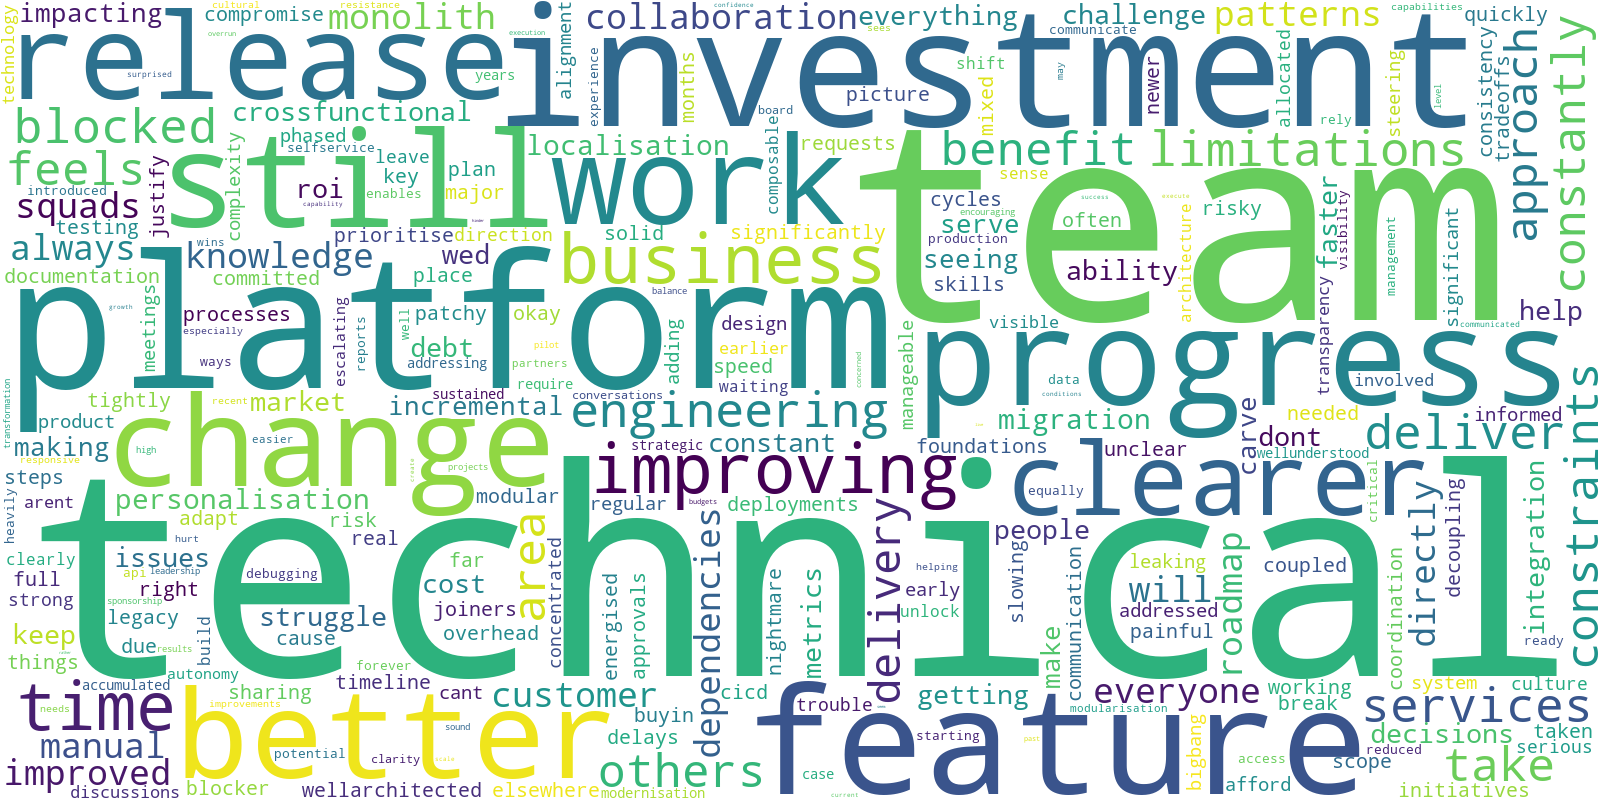

In [33]:
# Join the different processed titles together.
long_string = ','.join(list(text_data))
# Create a WordCloud object
wordcloud = WordCloud(
    collocations=False,
    normalize_plurals=True,
    background_color="white", 
    max_words=5000, 
    contour_width=3, 
    contour_color='steelblue',
    width=1600,  # Increased width
    height=800   # Increased height
)

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

### Stopwords and Tokenization

In [34]:
nltk.download('stopwords', quiet=True)
stop_words = stopwords.words('english')

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in gensim.utils.simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]

data = text_data.values.tolist()
data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
# Create Dictionary
id2word = corpora.Dictionary(data_words)
# Create Corpus
texts = data_words
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]
# View
print(corpus[:1][0][:30])

[(0, 2), (1, 2), (2, 2), (3, 1), (4, 2), (5, 1), (6, 2), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 3), (13, 1), (14, 1), (15, 2), (16, 2), (17, 6), (18, 4), (19, 2), (20, 2), (21, 1), (22, 2), (23, 4), (24, 2), (25, 4), (26, 1), (27, 2), (28, 1), (29, 2)]


### LDA model training

Create a model with 10 topics where each topic is a combination of keywords, and each keyword contributes a certain weightage to the topic.

In [35]:
from pprint import pprint

# number of topics
num_topics = 10
# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/cr0ss/Documents/Development/Migration-Readiness-

/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/cr0ss/Documents/Development/Migration-Readiness-Assessment/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


[(0,
  '0.020*"platform" + 0.017*"investment" + 0.014*"technical" + 0.014*"clearer" '
  '+ 0.013*"teams" + 0.012*"feels" + 0.011*"getting" + 0.011*"work" + '
  '0.011*"constraints" + 0.011*"progress"'),
 (1,
  '0.027*"investment" + 0.025*"everyone" + 0.021*"help" + 0.018*"technical" + '
  '0.018*"platform" + 0.017*"risk" + 0.015*"approach" + 0.015*"improving" + '
  '0.014*"migration" + 0.013*"take"'),
 (2,
  '0.017*"technical" + 0.016*"investment" + 0.016*"platform" + '
  '0.014*"approach" + 0.013*"teams" + 0.010*"work" + 0.010*"services" + '
  '0.010*"progress" + 0.010*"everyone" + 0.009*"keep"'),
 (3,
  '0.025*"progress" + 0.022*"still" + 0.020*"technical" + 0.020*"teams" + '
  '0.018*"services" + 0.017*"work" + 0.016*"time" + 0.015*"monolith" + '
  '0.014*"clearer" + 0.014*"knowledge"'),
 (4,
  '0.018*"teams" + 0.018*"technical" + 0.014*"platform" + 0.013*"blocked" + '
  '0.012*"constantly" + 0.012*"better" + 0.012*"work" + 0.012*"release" + '
  '0.011*"limitations" + 0.011*"changes

### Intertopic distance plot

In [36]:
import pickle

# Skip gensim LDA preparation if pre-computed data already exists
skip_gensim = os.path.exists('./Output/ldavis_prepared_' + str(num_topics))

# Visualize the topics
pyLDAvis.enable_notebook()
LDAvis_data_filepath = os.path.join('./Output/ldavis_prepared_'+str(num_topics))
# This is a bit time consuming - make the if statement True
# if you want to execute visualization prep yourself
if not skip_gensim:
    LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)
# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)
pyLDAvis.save_html(LDAvis_prepared, './Output/ldavis_prepared_'+ str(num_topics) +'.html')
LDAvis_prepared

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.175575 -0.176967       1        1  18.755969
3     -0.375589 -0.001589       2        1  18.743528
6      0.159386  0.073875       3        1  16.866208
5      0.165900  0.270493       4        1  14.500691
9      0.112059 -0.127907       5        1  14.500690
7      0.126062 -0.170122       6        1   9.018736
4      0.057921  0.310813       7        1   7.516872
8     -0.303137 -0.040360       8        1   0.032436
2     -0.256694  0.003759       9        1   0.032436
1      0.138515 -0.141995      10        1   0.032436, topic_info=           Term        Freq       Total Category  logprob  loglift
9          team  158.000000  158.000000  Default  30.0000  30.0000
6   opportunity  152.000000  152.000000  Default  29.0000  29.0000
4      longterm  148.000000  148.000000  Default  28.0000  28.0000
5     modernise  147.000000  147.000000  Default  27.0000  27.0000
0    decoupling  144.000000  144.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
37       strong    0.054096  130.251080  Topic10  -3.8693   0.2472
32   highimpact    0.053031  142.096301  Topic10  -3.8892   0.1403
35     monolith    0.043577  115.971276  Topic10  -4.0855   0.1471
13  engineering    0.048809  211.992360  Topic10  -3.9721  -0.3427
34       limits    0.042554  132.308067  Topic10  -4.1093  -0.0085

[357 rows x 6 columns], token_table=      Topic      Freq          Term
term                               
49        2  0.043038       ability
49        3  0.021519       ability
49        4  0.150634       ability
49        6  0.710133       ability
49        7  0.086077       ability
...     ...       ...           ...
48        6  0.013335  usespecially
59        2  0.021501    visibility
59        4  0.193510    visibility
59        6  0.666535    visibility
59        7  0.086005    visibility

[337 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 7, 6, 10, 8, 5, 9, 3, 2])

### Latent Dirichlet Allocation with online variational Bayes algorithm.

In [37]:
# Vectorize the text data
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
text_vectorized = vectorizer.fit_transform(text_data)

# Fit the LDA model
n_topics = 5  # Number of topics to extract
lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_model.fit(text_vectorized)

# Display the top words for each topic
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [words[i] for i in topic.argsort()[-10:]]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Topic 1: initiatives, approach, technical, help, roi, metrics, business, migration, platform, investment
Topic 2: engineering, technical, investment, improving, faster, dont, delivery, teams, changes, release
Topic 3: decisions, features, better, teams, limitations, constantly, deliver, blocked, platform, technical
Topic 4: engineering, technical, investment, improving, faster, dont, delivery, teams, changes, release
Topic 5: clearer, manual, monolith, knowledge, technical, work, time, services, teams, progress


## Sentiment Analysis

Using the NLTK library and VADER sentiment analyzer to evaluate the sentiments within the responses.

In [38]:
# Perform sentiment analysis on the qualitative responses
# Download the VADER lexicon if not already downloaded
nltk.download('vader_lexicon', quiet=True)

# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Perform sentiment analysis on the qualitative responses
sentiment_results = []

vader_mapped_qualitative_df = mapped_qualitative_df.copy()

for index, row in vader_mapped_qualitative_df.iterrows():
    # Combine all responses from a single row into one text
    combined_text = ' '.join(row.drop('role').dropna())
    
    # Get sentiment scores
    sentiment_scores = sia.polarity_scores(combined_text)
    
    # Append the results
    sentiment_results.append({
        'role': row['role'],
        'positive': sentiment_scores['pos'],
        'neutral': sentiment_scores['neu'],
        'negative': sentiment_scores['neg'],
        'compound': sentiment_scores['compound']
    })

# Convert the sentiment results into a DataFrame for better visualization
sentiment_df = pd.DataFrame(sentiment_results)

vader_mapped_qualitative_df = pd.concat([vader_mapped_qualitative_df, sentiment_df.drop(columns=['role'])], axis=1)

# Calculate average sentiment scores by role
average_sentiments_by_role = sentiment_df.groupby('role').mean().round(2)

print("\nAverage Sentiments by Role:")
print(average_sentiments_by_role)


Average Sentiments by Role:
             positive  neutral  negative  compound
role                                              
Business         0.18     0.74      0.09      0.99
Engineering      0.18     0.75      0.07      1.00
Leadership       0.18     0.76      0.06      0.99
Product          0.12     0.83      0.05      0.98


### Sentiment Plot

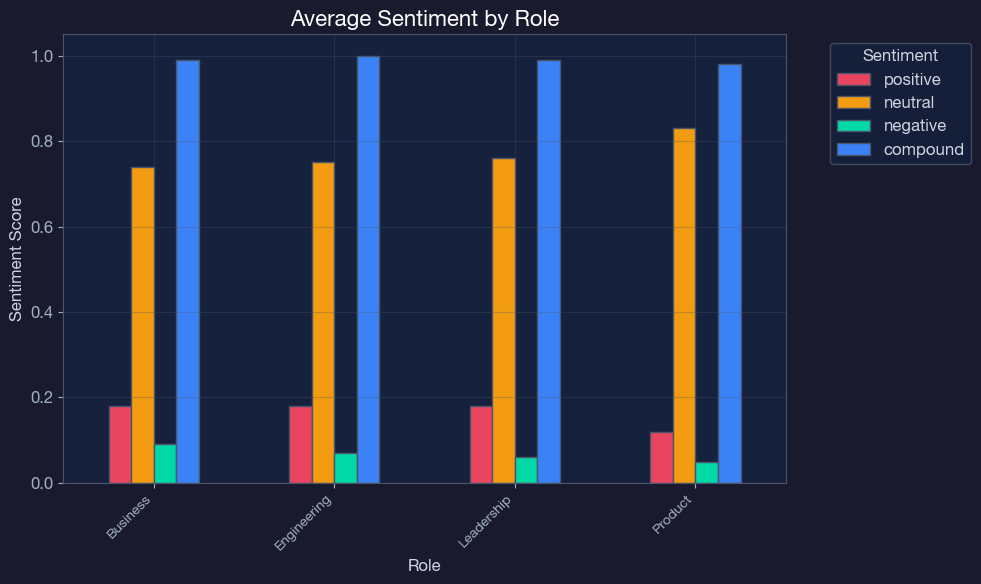

In [39]:
# Plot the average sentiment by role
average_sentiments_by_role.plot(kind='bar', figsize=(10, 6), edgecolor=_GRID_GRAY, color=MRA_PALETTE)

# Set plot labels and title
plt.title("Average Sentiment by Role", fontsize=16)
plt.xlabel("Role", fontsize=12)
plt.ylabel("Sentiment Score", fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha='right')
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()

## OpenAI

### Common themes across all roles

In [40]:
api_key = os.getenv('OPENAI_API_KEY')
openai.api_key = api_key

# Skip OpenAI API call if results already exist on disk
skip_open_ai = os.path.exists('./Output/analysis_results.txt')

def upload_df_to_openai(df):
    # store df to temporary file
    temp_file_path = Path("Output/combined_qualitative_df.csv")
    
    # Save the DataFrame to a temporary CSV file
    df.to_csv(temp_file_path, index=False)

    # Upload the file to OpenAI
    file = openai.files.create(
        file=temp_file_path.open("rb"),
        purpose="assistants",
    )

    # Wait for file to be processed
    while True:
        status = openai.files.retrieve(file.id)
        if status.status == "processed":
            break
        elif status.status == "failed":
            raise Exception("File processing failed.")
        time.sleep(1)  # Wait a bit before checking again

    # Remove the temporary file
    temp_file_path.unlink()

    return file.id

# Function to analyze sentiment and themes using OpenAI
def analyze_sentiment_and_themes(df, context_info=None):
    # Upload the DataFrame to OpenAI
    file_id = upload_df_to_openai(df)

    prompt = f"The csv file with the id { file_id } contains responses to a questionnaire. " \
        f"The header of the csv file contains the questions we've asked different roles in the organization. "\
        f"The column \"role\" contains the role of the person answering the questionnaire. " \
        f"The columns positive, neutral, negative and compound contain the sentiment scores for each response " \
        f"performed with the NLTK library and VADER sentiment analyzer. " \
        f"The rows contain responses from the various roles in the organization. " \
        f"Not every person had to answer every questions. Answering the questions was optional. " \
        f"Use this information to identify common opinions in the responses. " \
        f"Please analyze the responses and extract common themes across all roles and answers." \
        f"Additionally this context was provided: { context_info if context_info else 'No context provided.' }"
    instructions = "You are an expert in software migration projects, who is evaluating a questionnaire on Migration Readiness. " \
        "Expect no further instructions afterwards, therefore provide me with as much useful information as possible."

    if lda_model.components_ is not None:
        prompt += "\n\nThe following topics have already been identified in the responses performing a Latent Dirichlet Allocation (LDA).\n" \
            "Please use this information to identify common themes in the responses.\n\n"
    
    # Display the top words for each topic
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words = [words[i] for i in topic.argsort()[-10:]]
        prompt += f"Topic {topic_idx + 1}: {', '.join(top_words)}\n"
    prompt += "Please provide the results in a structured format, including the themes, their sentiment scores, and any relevant insights."
    try:    
        assistant = openai.beta.assistants.create(
            name="Software Migration Readiness Assistant",
            instructions=instructions,
            description="Analyzes CSV files and extract themes and sentiments.",
            model="gpt-4-turbo",
            top_p=threshold_statistical_significance,
            tools=[{"type": "code_interpreter"}]
        )

        thread = openai.beta.threads.create(
            tool_resources={
                "code_interpreter": {
                    "file_ids": [file_id]
                }
            }
        )

        message = openai.beta.threads.messages.create(
            thread_id=thread.id,
            role="user",
            content=prompt
        )

        run = openai.beta.threads.runs.create(
            thread_id=thread.id,
            assistant_id=assistant.id
        )

        while True:
            run_status = openai.beta.threads.runs.retrieve(
                thread_id=thread.id,
                run_id=run.id
            )
            if run_status.status == "completed":
                break
            elif run_status.status in ["failed", "cancelled", "expired"]:
                raise Exception(f"Run failed with status: {run_status.status}")
            time.sleep(1)
        
        messages_response = openai.beta.threads.messages.list(thread_id=thread.id)

        print("\nSentiment Analysis and Theme Extraction Results:")
        # Store extracted message values
        extracted_messages = []

        # If file already exists, delete it
        if Path("Output/analysis_results.txt").exists():
            Path("Output/analysis_results.txt").unlink()

        # Store messages to a file
        with open("Output/analysis_results.txt", "w") as f:
            for m in reversed(messages_response.data):
                value = m.content[0].text.value
                f.write(value + "\n")
                extracted_messages.append(value)
                print(value)

    except Exception as e:
        messages = f"Error: {e}"
        print(f"Error analyzing responses: {e}")

    # Clean up the file after processing
    openai.files.delete(file_id)
    # Clean up the thread
    openai.beta.threads.delete(thread_id=thread.id)
    # Clean up the assistant
    openai.beta.assistants.delete(assistant.id)

if not skip_open_ai:
    context_info = "These responses are related to a migration readiness assessment for a large organization."
    # Map the IDs in the header of the qualitative  to their corresponding questions
    question_mapping = questionnaire['Question'].to_dict()
    mapped_qualitative_df = vader_mapped_qualitative_df.rename(columns=question_mapping)
    analyze_sentiment_and_themes(mapped_qualitative_df, context_info=context_info)
else:
    print("Skipping continously calling OpenAI API")
    print("\n--------\n")
    print("Trying to display last results from OpenAI API from local storage.")
    # print content of "Output/analysis_results.txt" if present
    if Path("Output/analysis_results.txt").exists():
        with open("Output/analysis_results.txt", "r") as f:
            analysis_results = f.readlines()
            for line in analysis_results:
                print(line.strip())
    else:
        print("No analysis results found.")

Skipping continously calling OpenAI API

--------

Trying to display last results from OpenAI API from local storage.
The csv file with the id file-Ltvh22UUVwxgjg46MHJwm4 contains responses to a questionnaire. The header of the csv file contains the questions we've asked different roles in the organization. The column "role" contains the role of the person answering the questionnaire. The columns positive, neutral, negative and compound contain the sentiment scores for each response performed with the NLTK library and VADER sentiment analyzer. The rows contain responses from the various roles in the organization. Not every person had to answer every questions. Answering the questions was optional. Use this information to identify common opinions in the responses. Please analyze the responses and extract common themes across all roles and answers.Additionally this context was provided: These responses are related to a migration readiness assessment for a large organization.

The followi